# TITLE

In [1]:
#import necessary libraries and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats 
from scipy.optimize import curve_fit

## Loading Data

Processing data/Mill1.csv...
Processing data/Mill2.csv...
Processing data/Mill3.csv...
Processing data/Mill4.csv...
Success! Merged data from 1985-01-01 to 2025-11-27


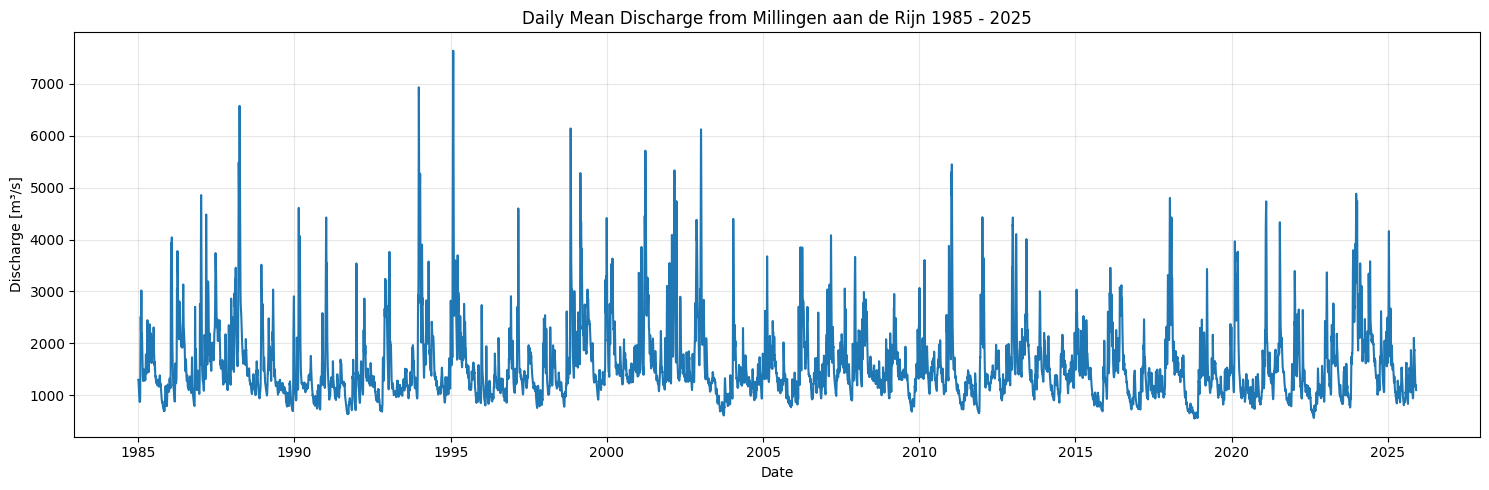

In [2]:
files = ['data/Mill1.csv', 'data/Mill2.csv', 'data/Mill3.csv', 'data/Mill4.csv']

data_frames = []

for file_name in files:
    # Check if file exists to prevent errors
    if os.path.exists(file_name):
        print(f"Processing {file_name}...")
        
        df = pd.read_csv(file_name, sep=';', encoding="latin1")
        df["datum"] = pd.to_datetime(df["datum"], dayfirst=True)
        df["waarde"] = pd.to_numeric(df["waarde"].astype(str).str.replace(",", "."))
        df.loc[df["waarde"] > 1e5, "waarde"] = np.nan 
        df = df.dropna(subset=["datum", "waarde"]) 
        
        # Calculate daily mean
        daily_part = df.groupby("datum")["waarde"].mean()
        data_frames.append(daily_part)
    else:
        print(f"Warning: {file_name} could not be found.")

if data_frames:
    Q_series = pd.concat(data_frames).sort_index()
    Q_series = Q_series.groupby(Q_series.index).mean() #removes overlapping dates

    print(f"Success! Merged data from {Q_series.index.min().date()} to {Q_series.index.max().date()}")

    # Plotting
    plt.figure(figsize=(15, 5))
    plt.plot(Q_series.index, Q_series.values)
    plt.xlabel("Date")
    plt.ylabel("Discharge [m³/s]")
    plt.title("Daily Mean Discharge from Millingen aan de Rijn 1985 - 2025")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No data was loaded.")

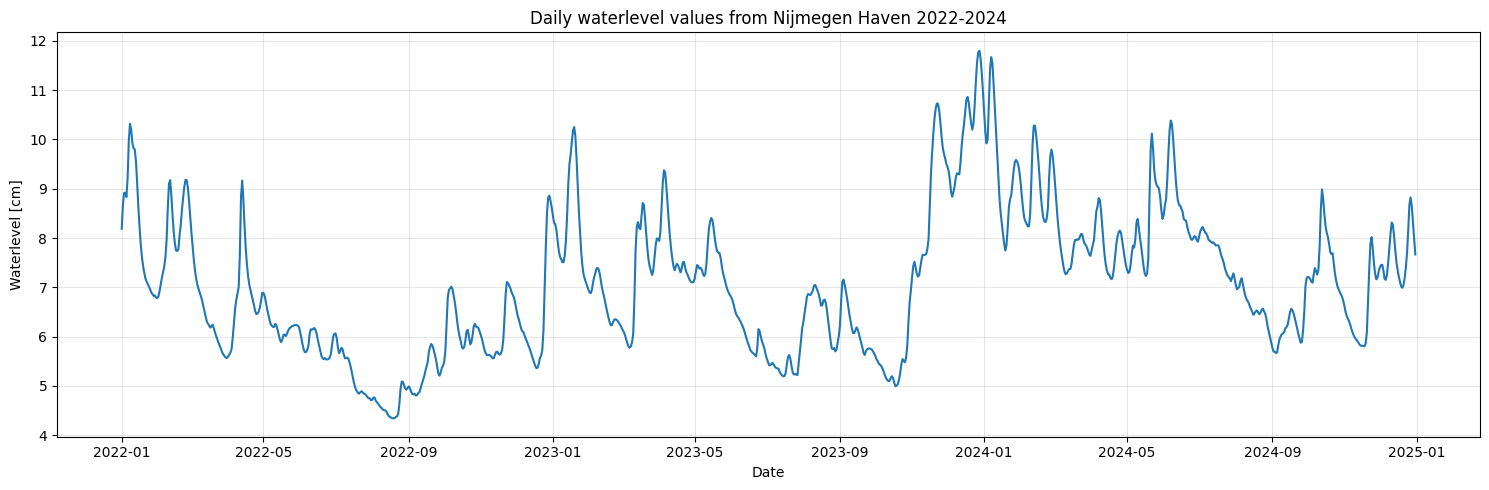

In [3]:
filename = 'data/nijmegen_haven_2022-2024.csv'
df_h = pd.read_csv(filename, sep=';', encoding="latin1")
df_h["datum"] = pd.to_datetime(df_h["WAARNEMINGDATUM"],dayfirst=True)
df_h["waarde"] = pd.to_numeric(df_h["NUMERIEKEWAARDE"].astype(str).str.replace(",", "."))
df_h.loc[df_h["waarde"] > 1e5, "waarde"] = np.nan 
df_h['waarde_meters'] = df_h['waarde'] / 100.0
df_h = df_h.dropna(subset=["datum", "waarde_meters"]) 
h_series = df_h.groupby("datum")["waarde_meters"].mean() # transform to daily mean 
#print(h_series.index)

plt.figure(figsize=(15, 5))
plt.plot(h_series.index, h_series.values)
plt.xlabel("Date")
plt.ylabel("Waterlevel [cm]")
plt.title(f"Daily waterlevel values from Nijmegen Haven 2022-2024")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Total Combined Days: 1092


/var/folders/4y/hg49x_715k776wft9dbb2rrr0000gp/T/ipykernel_97446/1873387192.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


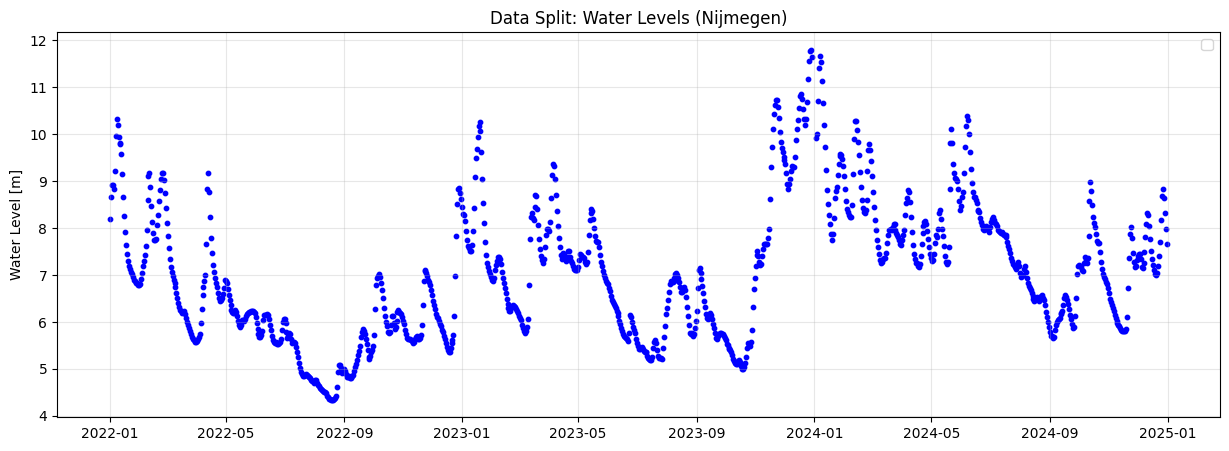

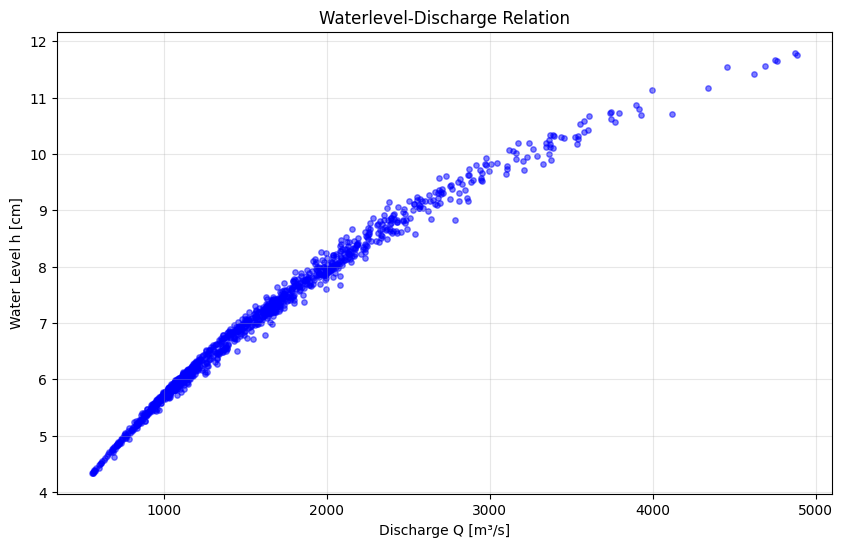

In [4]:
# Split data into training and validation sets.
combined_df = pd.concat([Q_series, h_series], axis=1, join='inner')
combined_df.columns = ['Q_m3s', 'h_meters']
training_data = combined_df.loc['2022-01-01':'2023-12-31'].copy()
validation_data = combined_df.loc['2024-01-01':'2024-12-31'].copy()
# display(training_data)
print(f"Total Combined Days: {len(combined_df)}")
# print(f"Training Samples (2022-2023): {len(training_data)}")
# print(f"Validation Samples (2024): {len(validation_data)}")

Q_train = training_data['Q_m3s'].values
h_train = training_data['h_meters'].values

Q_val = validation_data['Q_m3s'].values
h_val = validation_data['h_meters'].values

Q_combined = combined_df['Q_m3s'].values
h_combined = combined_df['h_meters'].values

plt.figure(figsize=(15, 5))
plt.scatter(training_data.index, training_data['h_meters'], s=10, color='blue')
plt.scatter(validation_data.index, validation_data['h_meters'], s=10, color='blue')
plt.title("Data Split: Water Levels (Nijmegen)")
plt.ylabel("Water Level [m]")
plt.legend()
plt.grid(True, alpha=0.3)

plt.figure(figsize=(10, 6))

# Plot Training Data
plt.scatter(Q_train, h_train, s=15, alpha=0.5, color='blue')

# Plot Validation Data
plt.scatter(Q_val, h_val, s=15, alpha=0.5, color='blue')

plt.xlabel("Discharge Q [m³/s]")
plt.ylabel("Water Level h [cm]")
plt.title("Waterlevel-Discharge Relation")
plt.grid(True, alpha=0.3)
plt.show()

## Pre-Calibration

In [5]:
def fit_func(Q, a, b, h0):
    return h0 + np.power(np.maximum(Q/a, 1e-9), 1.0/b)

# Initial guesses for the optimizer (Order: a, b, h0)
# a ~ 0.05 (scale), b ~ 1.5 (shape), h0 ~ 300 (must be < lowest h)
p0_guess = [0.05, 1.5, np.min(h_train) - 100]

# Bounds: ((min_a, min_b, min_h0), (max_a, max_b, max_h0))
# a > 0, b > 0, h0 < min_h_train
bounds = ((1e-5, 0.5, -np.inf), (100, 5.0, np.min(h_train) - 10))

# Run the optimizer
p_opt, p_cov = curve_fit(fit_func, Q_combined, h_combined, p0=p0_guess, bounds=bounds, maxfev=10000)

a_best, b_best, h0_best = p_opt
print("\n--- Optimized Starting Points ---")
print(f"Best a:  {a_best:.5f}")
print(f"Best b:  {b_best:.5f}")
print(f"Best h0: {h0_best:.5f}")

# Calculate the residual standard deviation (sigma) from this best fit
residuals = h_train - fit_func(Q_train, *p_opt)
sigma_best = np.std(residuals)
print(f"Best sigma: {sigma_best:.5f}")


--- Optimized Starting Points ---
Best a:  0.12499
Best b:  3.70055
Best h0: -5.65715
Best sigma: 0.10635


In [6]:
def stage_discharge_model(Q, a, b, h0):
    term = np.maximum(Q / a, 0)
    return h0 + np.power(term, 1.0/b)

def log_prior(theta):
    a, b, h0, log_sigma = theta

    if a <= 0 or b <= 0:
        return -np.inf
    
    min_h = np.min(h_train) # minimum value of the river bed must be lower than minimum water level observed
    if h0 >= min_h: 
        return -np.inf
    return -0.5 * (log_sigma**2)

def log_likelihood(theta, Q_data, h_data):
    a, b, h0, log_sigma = theta
    sigma = np.exp(log_sigma)

    h_model = stage_discharge_model(Q_data, a, b, h0)
    residuals = h_data - h_model

    n = len(h_data)
    log_lik = -n * np.log(sigma) - 0.5 * n * np.log(2 * np.pi) - 0.5 * np.sum((residuals / sigma)**2)
    return log_lik

def log_posterior(theta, Q_data, h_data):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, Q_data, h_data)

Iteration 2000/100000 | Acceptance Rate: 0.09
Iteration 4000/100000 | Acceptance Rate: 0.05
Iteration 6000/100000 | Acceptance Rate: 0.04
Iteration 8000/100000 | Acceptance Rate: 0.03
Iteration 10000/100000 | Acceptance Rate: 0.03
Iteration 12000/100000 | Acceptance Rate: 0.02
Iteration 14000/100000 | Acceptance Rate: 0.02
Iteration 16000/100000 | Acceptance Rate: 0.02
Iteration 18000/100000 | Acceptance Rate: 0.02
Iteration 20000/100000 | Acceptance Rate: 0.01
Iteration 22000/100000 | Acceptance Rate: 0.01
Iteration 24000/100000 | Acceptance Rate: 0.01
Iteration 26000/100000 | Acceptance Rate: 0.01
Iteration 28000/100000 | Acceptance Rate: 0.01
Iteration 30000/100000 | Acceptance Rate: 0.01
Iteration 32000/100000 | Acceptance Rate: 0.01
Iteration 34000/100000 | Acceptance Rate: 0.01
Iteration 36000/100000 | Acceptance Rate: 0.01
Iteration 38000/100000 | Acceptance Rate: 0.01
Iteration 40000/100000 | Acceptance Rate: 0.01
Iteration 42000/100000 | Acceptance Rate: 0.01
Iteration 44000/1

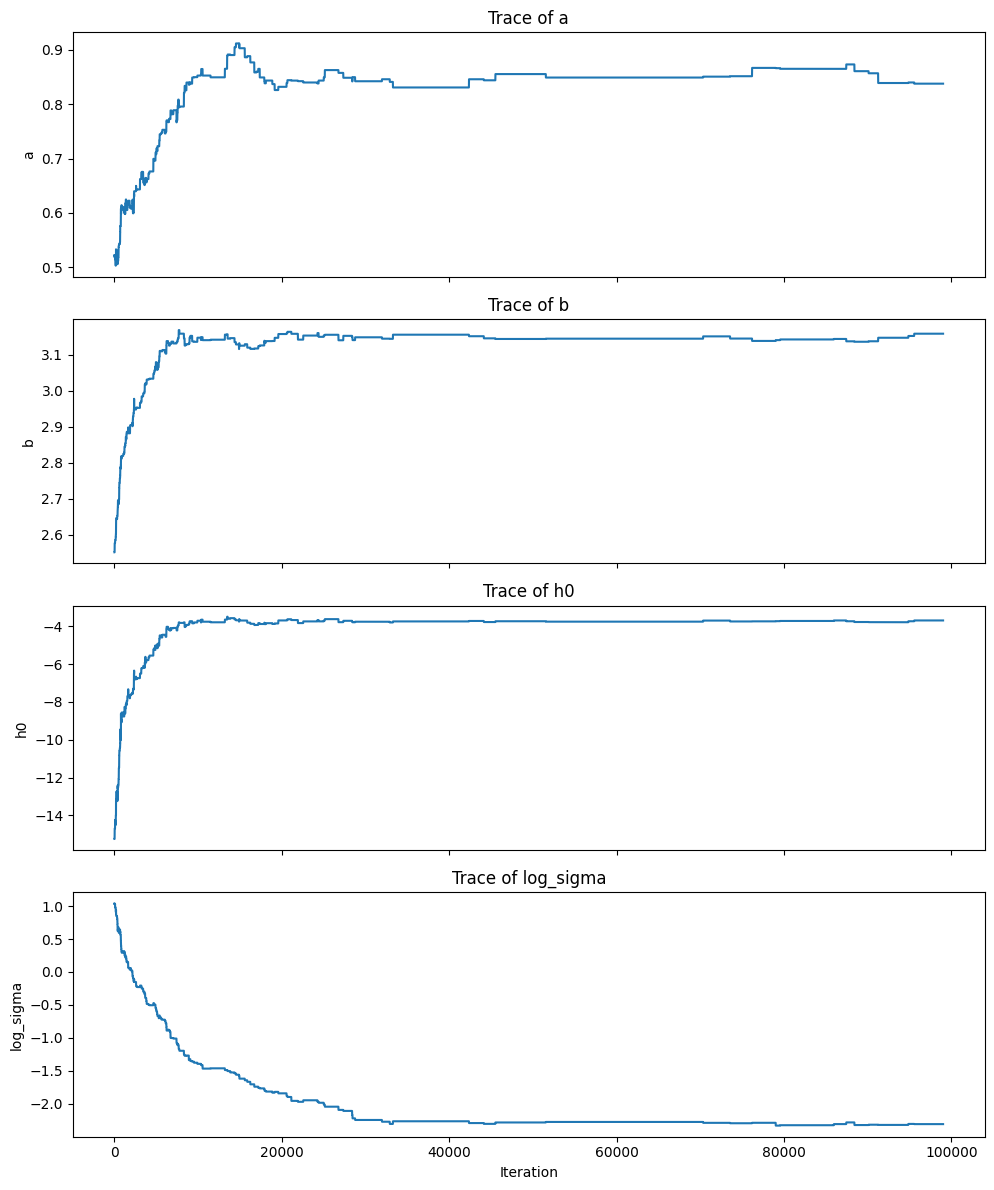

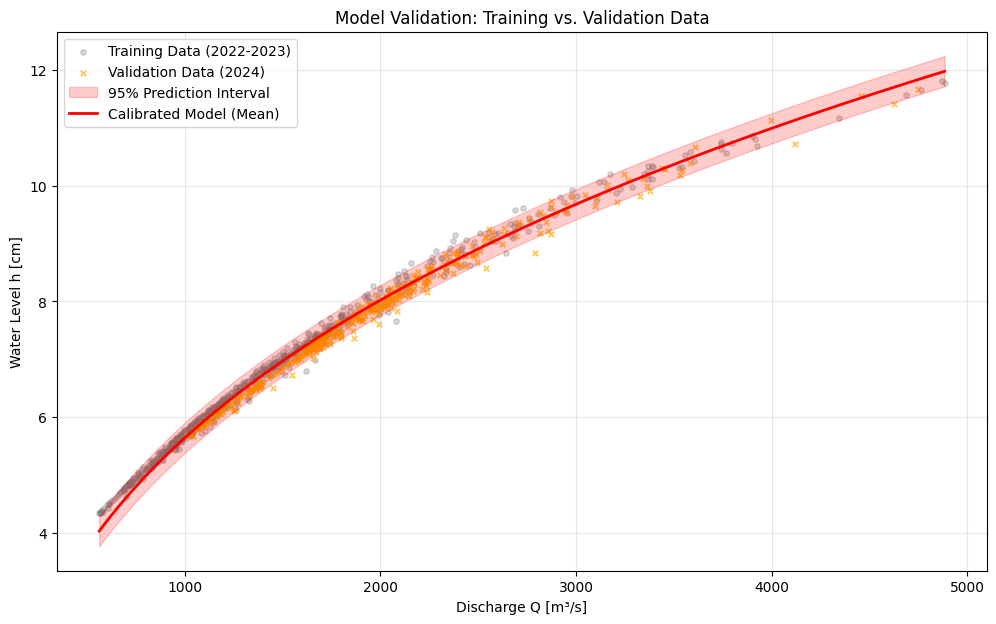

In [7]:

initial_h0 = np.min(h_train) - 50
initial_theta = np.array([0.01, 1.8, 5, 0.2])
step_sizes = np.array([
    0.01, 
    0.01,
    5, 
    0.03
])
n_iterations = 100000
burn_in = 1000

chain = np.zeros((n_iterations, 4))
chain[0] = initial_theta
current_log_post = log_posterior(initial_theta, Q_train, h_train)

accepted = 0

for i in range(1, n_iterations):
    # A. Propose new parameter set (Perturbation)
    proposal = chain[i-1] + np.random.normal(0, 1, 4) * step_sizes
    
    # B. Calculate Posterior for Proposal
    proposal_log_post = log_posterior(proposal, Q_train, h_train)
    
    # C. Calculate Acceptance Probability (alpha)
    log_alpha = proposal_log_post - current_log_post
    
    # D. Accept or Reject
    # Compare log_alpha to log(uniform_random)
    if np.log(np.random.rand()) < log_alpha:
        # Accept
        chain[i] = proposal
        current_log_post = proposal_log_post
        accepted += 1
    else:
        # Reject (Stay at current state)
        chain[i] = chain[i-1]
        
    if i % 2000 == 0:
        print(f"Iteration {i}/{n_iterations} | Acceptance Rate: {accepted/i:.2f}")

print("MCMC Finished.")

samples = chain[burn_in:]

# Calculate Best Fit (Mean of Posterior)
a_est = np.mean(samples[:, 0])
b_est = np.mean(samples[:, 1])
h0_est = np.mean(samples[:, 2])
sigma_est = np.exp(np.mean(samples[:, 3]))

print("\n--- Calibrated Parameters ---")
print(f"a  (Scale) : {a_est:.4f}")
print(f"b  (Shape) : {b_est:.4f}")
print(f"h0 (Offset): {h0_est:.4f}")
print(f"sigma (Err): {sigma_est:.4f}")

# Plot Traceplots (Like A1_1_MCMC)
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
param_names = ['a', 'b', 'h0', 'log_sigma']

for j, ax in enumerate(axes):
    ax.plot(samples[:, j])
    ax.set_ylabel(param_names[j])
    ax.set_title(f"Trace of {param_names[j]}")

plt.xlabel("Iteration")
plt.tight_layout()
plt.show()

# Plot Fit
plt.figure(figsize=(12, 7))

# 1. Plot Training Data (The data the model learned from)
plt.scatter(Q_train, h_train, alpha=0.3, label='Training Data (2022-2023)', color='gray', s=15)

# 2. Plot Validation Data (The "Test" - 2024)
plt.scatter(Q_val, h_val, alpha=0.6, label='Validation Data (2024)', color='orange', s=15, marker='x')

# 3. Generate the Model Curve
# We extend the range to cover both training and validation discharges
Q_min = min(np.min(Q_train), np.min(Q_val))
Q_max = max(np.max(Q_train), np.max(Q_val))
Q_range = np.linspace(Q_min, Q_max, 200)

# Calculate the mean curve
h_mean_fit = stage_discharge_model(Q_range, a_est, b_est, h0_est)

# 4. Calculate 95% Prediction Interval (Crucial for validation!)
# This adds the model error (sigma) to show where future points should land
upper_bound = h_mean_fit + 1.96 * sigma_est
lower_bound = h_mean_fit - 1.96 * sigma_est

# Plot the intervals
plt.fill_between(Q_range, lower_bound, upper_bound, color='red', alpha=0.2, label='95% Prediction Interval')
plt.plot(Q_range, h_mean_fit, color='red', linewidth=2, label='Calibrated Model (Mean)')

plt.xlabel("Discharge Q [m³/s]")
plt.ylabel("Water Level h [cm]")
plt.title("Model Validation: Training vs. Validation Data")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Starting MCMC...
Iteration 5000/100000 | Acceptance Rate: 5.10%
Iteration 10000/100000 | Acceptance Rate: 2.96%
Iteration 15000/100000 | Acceptance Rate: 2.07%
Iteration 20000/100000 | Acceptance Rate: 1.58%
Iteration 25000/100000 | Acceptance Rate: 1.29%
Iteration 30000/100000 | Acceptance Rate: 1.09%
Iteration 35000/100000 | Acceptance Rate: 0.94%
Iteration 40000/100000 | Acceptance Rate: 0.83%
Iteration 45000/100000 | Acceptance Rate: 0.74%
Iteration 50000/100000 | Acceptance Rate: 0.67%
Iteration 55000/100000 | Acceptance Rate: 0.61%
Iteration 60000/100000 | Acceptance Rate: 0.56%
Iteration 65000/100000 | Acceptance Rate: 0.52%
Iteration 70000/100000 | Acceptance Rate: 0.49%
Iteration 75000/100000 | Acceptance Rate: 0.46%
Iteration 80000/100000 | Acceptance Rate: 0.43%
Iteration 85000/100000 | Acceptance Rate: 0.40%
Iteration 90000/100000 | Acceptance Rate: 0.38%
Iteration 95000/100000 | Acceptance Rate: 0.37%
MCMC Finished.

--- Calibrated Parameters ---
a  (Scale) : 0.7102
b  (Sh

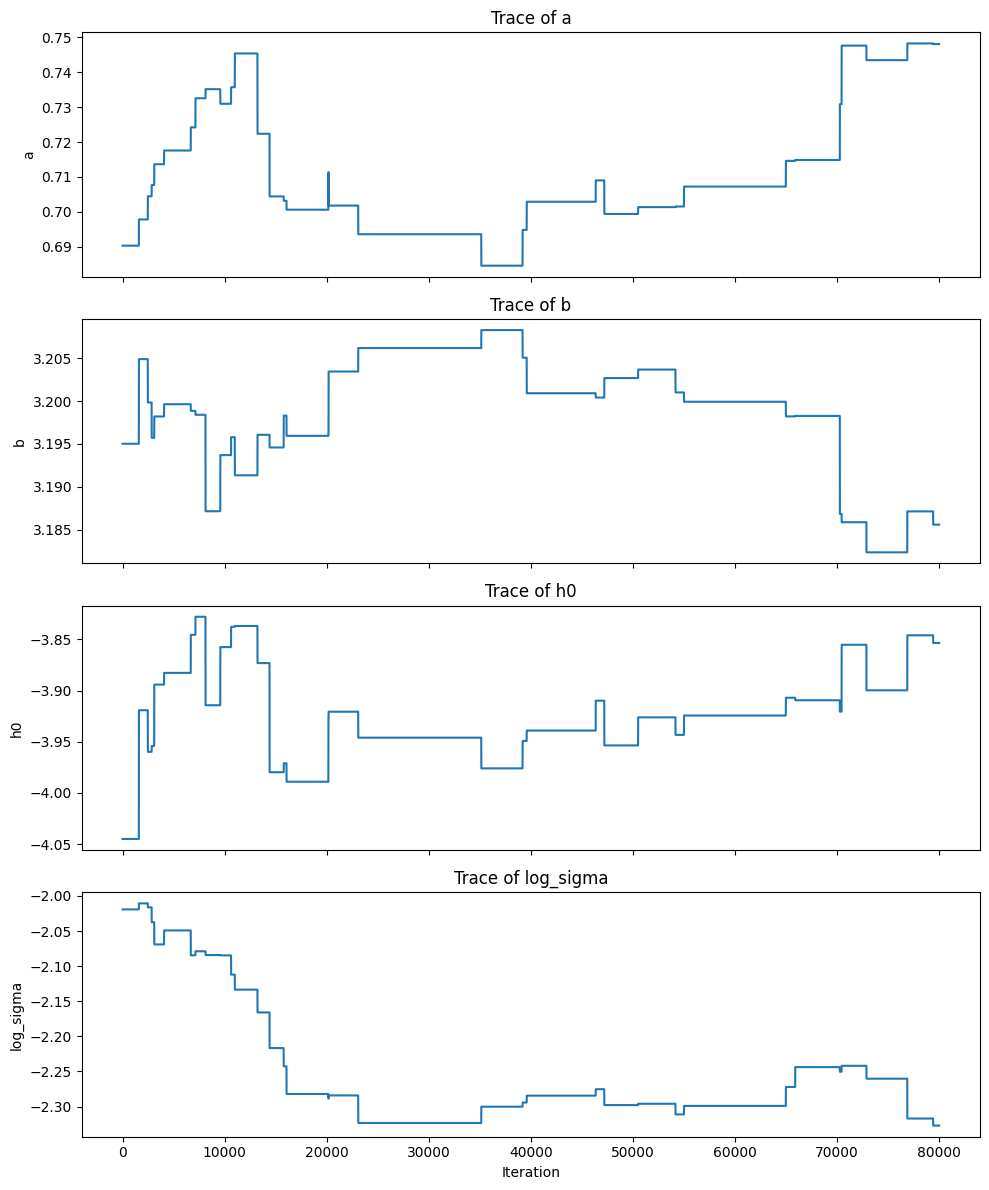

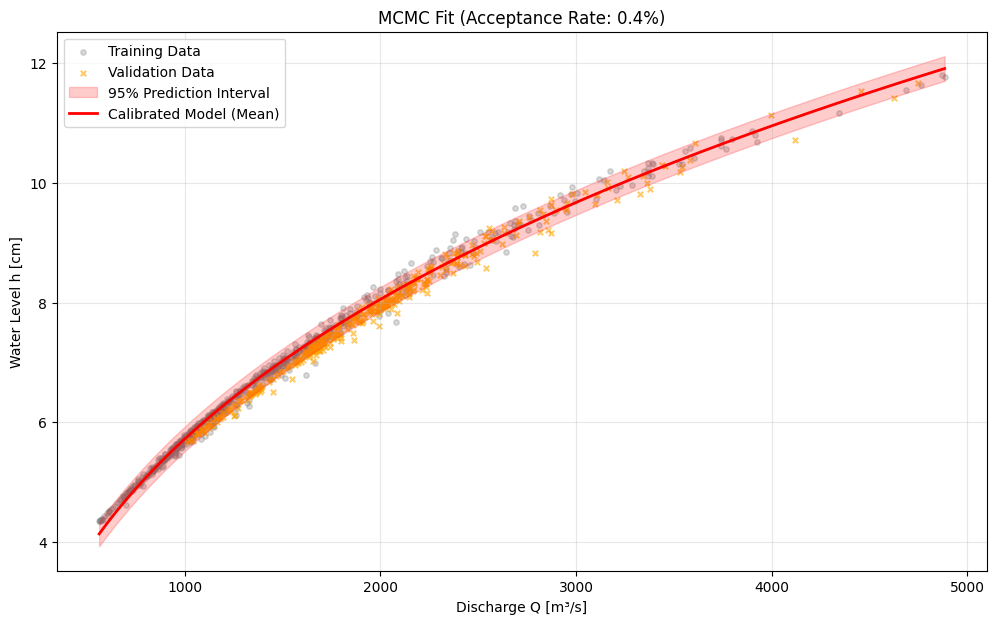

In [8]:
# --- 2. Setup MCMC Initialization ---

# Starting Guesses
initial_h0 = np.min(h_train) - 50
initial_theta = np.array([0.01, 1.8, 5, 0.2]) # [a, b, h0, log_sigma]

# --- NEW: Setup Multivariate Proposal ---
# Your original step sizes (standard deviations)
raw_step_sizes = np.array([0.01, 0.01, 5, 0.03])

# Create the Covariance Matrix (Diagonal of variances)
# Variance = Standard_Deviation^2
cov_prop = np.diag(raw_step_sizes**2)

# Mean of the jump (Zero, because we want a random walk centered on current state)
mu_prop = np.zeros(4)

# MCMC Settings
n_iterations = 100000
burn_in = 20000  # Recommend discarding the first few thousand

chain = np.zeros((n_iterations, 4))
chain[0] = initial_theta
current_log_post = log_posterior(initial_theta, Q_train, h_train)

accepted = 0

# --- 3. Run MCMC Loop ---

print("Starting MCMC...")

for i in range(1, n_iterations):
    
    # A. Propose new parameter set using Multivariate Normal
    # This replaces: chain[i-1] + np.random.normal(...)
    perturbation = stats.multivariate_normal.rvs(mean=mu_prop, cov=cov_prop)
    proposal = chain[i-1] + perturbation
    
    # B. Calculate Posterior for Proposal
    proposal_log_post = log_posterior(proposal, Q_train, h_train)
    
    # C. Calculate Acceptance Probability (Metropolis Step)
    # We use log scale subtraction (log(alpha) = log(p_new) - log(p_old))
    log_alpha = proposal_log_post - current_log_post
    
    # D. Accept or Reject
    # Sample uniform random u in [0,1], take log, compare to log_alpha
    if np.log(np.random.rand()) < log_alpha:
        # Accept
        chain[i] = proposal
        current_log_post = proposal_log_post
        accepted += 1
    else:
        # Reject (Stay at previous state)
        chain[i] = chain[i-1]
        
    if i % 5000 == 0:
        print(f"Iteration {i}/{n_iterations} | Acceptance Rate: {accepted/i:.2%}")

print("MCMC Finished.")

# --- 4. Analysis and Plotting ---

samples = chain[burn_in:]

# Calculate Best Fit (Mean of Posterior)
a_est = np.mean(samples[:, 0])
b_est = np.mean(samples[:, 1])
h0_est = np.mean(samples[:, 2])
sigma_est = np.exp(np.mean(samples[:, 3]))

print("\n--- Calibrated Parameters ---")
print(f"a  (Scale) : {a_est:.4f}")
print(f"b  (Shape) : {b_est:.4f}")
print(f"h0 (Offset): {h0_est:.4f}")
print(f"sigma (Err): {sigma_est:.4f}")
print(f"Acceptance Rate: {accepted/n_iterations:.2%}")

# Plot Traceplots
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
param_names = ['a', 'b', 'h0', 'log_sigma']

for j, ax in enumerate(axes):
    ax.plot(samples[:, j])
    ax.set_ylabel(param_names[j])
    ax.set_title(f"Trace of {param_names[j]}")

plt.xlabel("Iteration")
plt.tight_layout()
plt.show()

# Plot Model Fit
plt.figure(figsize=(12, 7))

# Plot Data
plt.scatter(Q_train, h_train, alpha=0.3, label='Training Data', color='gray', s=15)
plt.scatter(Q_val, h_val, alpha=0.6, label='Validation Data', color='orange', s=15, marker='x')

# Generate Model Curve
Q_min = min(np.min(Q_train), np.min(Q_val))
Q_max = max(np.max(Q_train), np.max(Q_val))
Q_range = np.linspace(Q_min, Q_max, 200)

h_mean_fit = stage_discharge_model(Q_range, a_est, b_est, h0_est)

# Prediction Intervals (95%)
upper_bound = h_mean_fit + 1.96 * sigma_est
lower_bound = h_mean_fit - 1.96 * sigma_est

plt.fill_between(Q_range, lower_bound, upper_bound, color='red', alpha=0.2, label='95% Prediction Interval')
plt.plot(Q_range, h_mean_fit, color='red', linewidth=2, label='Calibrated Model (Mean)')

plt.xlabel("Discharge Q [m³/s]")
plt.ylabel("Water Level h [cm]")
plt.title(f"MCMC Fit (Acceptance Rate: {accepted/n_iterations:.1%})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Guess based on converged values 

Starting MCMC...
Iteration 2000/50000 | Acceptance Rate: 14.20%
Iteration 4000/50000 | Acceptance Rate: 8.82%
Iteration 6000/50000 | Acceptance Rate: 6.47%
Iteration 8000/50000 | Acceptance Rate: 5.16%
Iteration 10000/50000 | Acceptance Rate: 4.22%
Iteration 12000/50000 | Acceptance Rate: 3.56%
Iteration 14000/50000 | Acceptance Rate: 3.07%
Iteration 16000/50000 | Acceptance Rate: 2.69%
Iteration 18000/50000 | Acceptance Rate: 2.39%
Iteration 20000/50000 | Acceptance Rate: 2.17%
Iteration 22000/50000 | Acceptance Rate: 1.98%
Iteration 24000/50000 | Acceptance Rate: 1.82%
Iteration 26000/50000 | Acceptance Rate: 1.68%
Iteration 28000/50000 | Acceptance Rate: 1.56%
Iteration 30000/50000 | Acceptance Rate: 1.46%
Iteration 32000/50000 | Acceptance Rate: 1.38%
Iteration 34000/50000 | Acceptance Rate: 1.29%
Iteration 36000/50000 | Acceptance Rate: 1.23%
Iteration 38000/50000 | Acceptance Rate: 1.16%
Iteration 40000/50000 | Acceptance Rate: 1.10%
Iteration 42000/50000 | Acceptance Rate: 1.05%

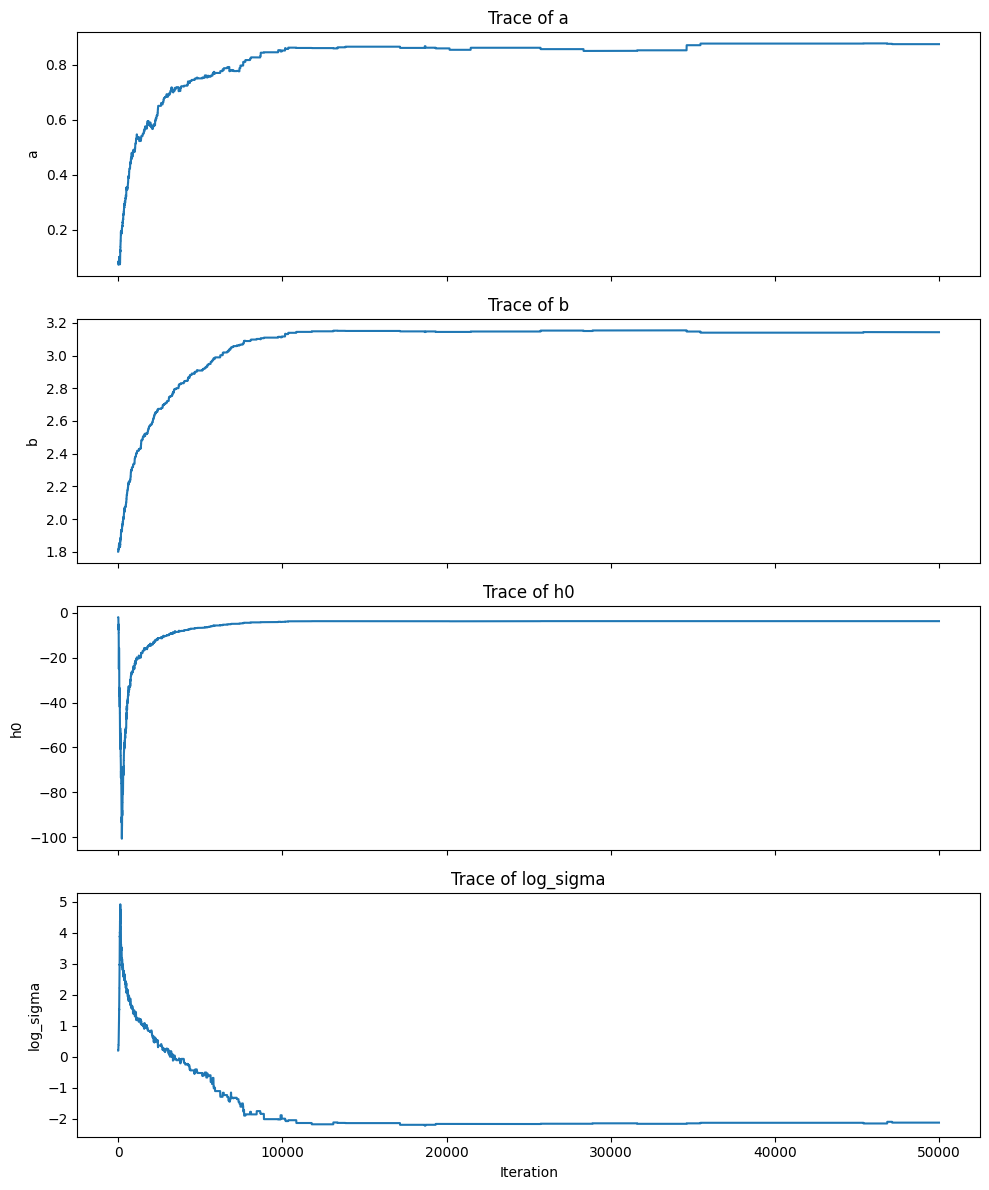

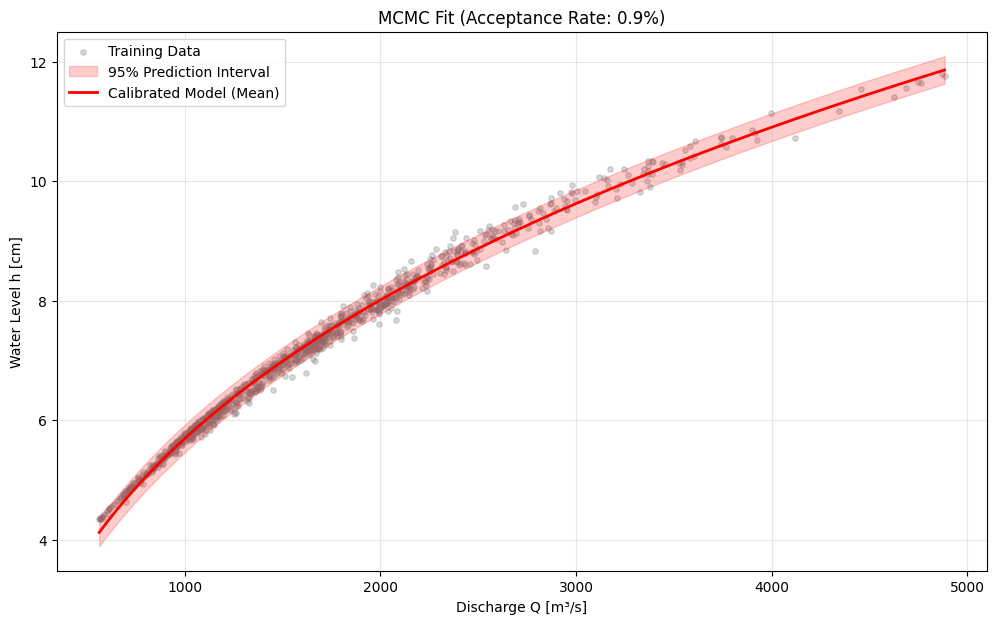

In [9]:
# --- 2. Setup MCMC Initialization ---
# Starting Guesses
initial_theta = np.array([0.08, 1.8, -2, 0.2]) # [a, b, h0, log_sigma]

# --- NEW: Setup Multivariate Proposal ---
# Your original step sizes (standard deviations)
raw_step_sizes = np.array([0.005, 0.005, 2.5, 0.1])

# Create the Covariance Matrix (Diagonal of variances)
# Variance = Standard_Deviation^2
cov_prop = np.diag(raw_step_sizes**2)

# Mean of the jump (Zero, because we want a random walk centered on current state)
mu_prop = np.zeros(4)

# MCMC Settings
n_iterations = 50000
burn_in = 20000  # Recommend discarding the first few thousand

chain = np.zeros((n_iterations, 4))
chain[0] = initial_theta
current_log_post = log_posterior(initial_theta, Q_combined, h_combined)

accepted = 0

# --- 3. Run MCMC Loop ---

print("Starting MCMC...")

for i in range(1, n_iterations):
    
    # A. Propose new parameter set using Multivariate Normal
    # This replaces: chain[i-1] + np.random.normal(...)
    perturbation = stats.multivariate_normal.rvs(mean=mu_prop, cov=cov_prop)
    proposal = chain[i-1] + perturbation
    
    # B. Calculate Posterior for Proposal
    proposal_log_post = log_posterior(proposal, Q_combined, h_combined)
    
    # C. Calculate Acceptance Probability (Metropolis Step)
    # We use log scale subtraction (log(alpha) = log(p_new) - log(p_old))
    log_alpha = proposal_log_post - current_log_post
    
    # D. Accept or Reject
    # Sample uniform random u in [0,1], take log, compare to log_alpha
    if np.log(np.random.rand()) < log_alpha:
        # Accept
        chain[i] = proposal
        current_log_post = proposal_log_post
        accepted += 1
    else:
        # Reject (Stay at previous state)
        chain[i] = chain[i-1]
        
    if i % 2000 == 0:
        print(f"Iteration {i}/{n_iterations} | Acceptance Rate: {accepted/i:.2%}")

print("MCMC Finished.")

# --- 4. Analysis and Plotting ---

samples = chain[burn_in:]

# Calculate Best Fit (Mean of Posterior)
a_est = np.mean(samples[:, 0])
b_est = np.mean(samples[:, 1])
h0_est = np.mean(samples[:, 2])
sigma_est = np.exp(np.mean(samples[:, 3]))

print("\n--- Calibrated Parameters ---")
print(f"a  (Scale) : {a_est:.4f}")
print(f"b  (Shape) : {b_est:.4f}")
print(f"h0 (Offset): {h0_est:.4f}")
print(f"sigma (Err): {sigma_est:.4f}")
print(f"Acceptance Rate: {accepted/n_iterations:.2%}")

# Plot Traceplots
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
param_names = ['a', 'b', 'h0', 'log_sigma']

for j, ax in enumerate(axes):
    ax.plot(chain[:, j])
    ax.set_ylabel(param_names[j])
    ax.set_title(f"Trace of {param_names[j]}")

plt.xlabel("Iteration")
plt.tight_layout()
plt.show()

# Plot Model Fit
plt.figure(figsize=(12, 7))

# Plot Data
plt.scatter(Q_combined, h_combined, alpha=0.3, label='Training Data', color='gray', s=15)
# plt.scatter(Q_val, h_val, alpha=0.6, label='Validation Data', color='orange', s=15, marker='x')

# Generate Model Curve
Q_min = min(np.min(Q_combined), np.min(Q_val))
Q_max = max(np.max(Q_combined), np.max(Q_val))
Q_range = np.linspace(Q_min, Q_max, 200)

h_mean_fit = stage_discharge_model(Q_range, a_est, b_est, h0_est)

# Prediction Intervals (95%)
upper_bound = h_mean_fit + 1.96 * sigma_est
lower_bound = h_mean_fit - 1.96 * sigma_est

plt.fill_between(Q_range, lower_bound, upper_bound, color='red', alpha=0.2, label='95% Prediction Interval')
plt.plot(Q_range, h_mean_fit, color='red', linewidth=2, label='Calibrated Model (Mean)')

plt.xlabel("Discharge Q [m³/s]")
plt.ylabel("Water Level h [cm]")
plt.title(f"MCMC Fit (Acceptance Rate: {accepted/n_iterations:.1%})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Guess based on priors

In [56]:
# Prior settings
prior_mu_a = 10       # Expected value for a
prior_sigma_a = 10   # Uncertainty for a

prior_mu_b = 2.3       # Expected value for b
prior_sigma_b = 0.5     # Uncertainty for b

prior_mu_h0 = -2.0      # Expected bed level
prior_sigma_h0 = 0.5    # Uncertainty for h0

prior_mu_log_sigma = np.log(0.1)  # Expected log(sigma)
prior_sigma_log_sigma = 0.5       # Uncertainty for log(sigma)

# --- 1. Define Model and Probability Functions ---

def stage_discharge_model(Q, a, b, h0):
    # h = h0 + (Q/a)^(1/b)
    term = np.maximum(Q / a, 0)
    return h0 + np.power(term, 1.0/b)

def log_prior(theta):
    a, b, h0, log_sigma = theta

    # --- A. Hard Constraints (Truncation) ---
    # We must still enforce physical limits (Truncated Normal)
    if a <= 0 or b <= 0:
        return -np.inf
    
    # Constraint: h0 (bed level) must be below lowest observed water level
    # Note: Ensure h_combined is defined in your workspace or passed as an arg
    min_h = np.min(h_combined) 
    if h0 >= min_h: 
        return -np.inf

    # --- B. Gaussian (Normal) Priors using Scipy ---
    # stats.norm.logpdf(x, loc=mean, scale=std_dev)
    
    lp_a  = stats.norm.logpdf(a, loc=prior_mu_a, scale=prior_sigma_a)
    lp_b  = stats.norm.logpdf(b, loc=prior_mu_b, scale=prior_sigma_b)
    lp_h0 = stats.norm.logpdf(h0, loc=prior_mu_h0, scale=prior_sigma_h0)
    
    lp_sigma = stats.norm.logpdf(
        log_sigma,
        loc=prior_mu_log_sigma,
        scale=prior_sigma_log_sigma
    )

    return lp_a + lp_b + lp_h0 + lp_sigma

def log_likelihood(theta, Q_data, h_data):
    a, b, h0, log_sigma = theta
    sigma = np.exp(log_sigma)

    if (not np.isfinite(sigma)) or (sigma <= 0):
        return -np.inf

    h_model = stage_discharge_model(Q_data, a, b, h0)
    residuals = h_data - h_model

    log_lik = np.sum(stats.norm.logpdf(residuals, loc=0.0, scale=sigma))
    return log_lik

def log_posterior(theta, Q_data, h_data):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, Q_data, h_data)

Starting MCMC using Scipy Stats...
Iteration 2000/50000 | Acceptance Rate: 29.15%
Iteration 4000/50000 | Acceptance Rate: 15.93%
Iteration 6000/50000 | Acceptance Rate: 11.55%
Iteration 8000/50000 | Acceptance Rate: 9.22%
Iteration 10000/50000 | Acceptance Rate: 7.90%
Iteration 12000/50000 | Acceptance Rate: 7.08%
Iteration 14000/50000 | Acceptance Rate: 6.59%
Iteration 16000/50000 | Acceptance Rate: 6.08%
Iteration 18000/50000 | Acceptance Rate: 5.78%
Iteration 20000/50000 | Acceptance Rate: 5.42%
Iteration 22000/50000 | Acceptance Rate: 5.18%
Iteration 24000/50000 | Acceptance Rate: 4.95%
Iteration 26000/50000 | Acceptance Rate: 4.72%
Iteration 28000/50000 | Acceptance Rate: 4.56%
Iteration 30000/50000 | Acceptance Rate: 4.40%
Iteration 32000/50000 | Acceptance Rate: 4.28%
Iteration 34000/50000 | Acceptance Rate: 4.19%
Iteration 36000/50000 | Acceptance Rate: 4.10%
Iteration 38000/50000 | Acceptance Rate: 4.03%
Iteration 40000/50000 | Acceptance Rate: 3.96%
Iteration 42000/50000 | Ac

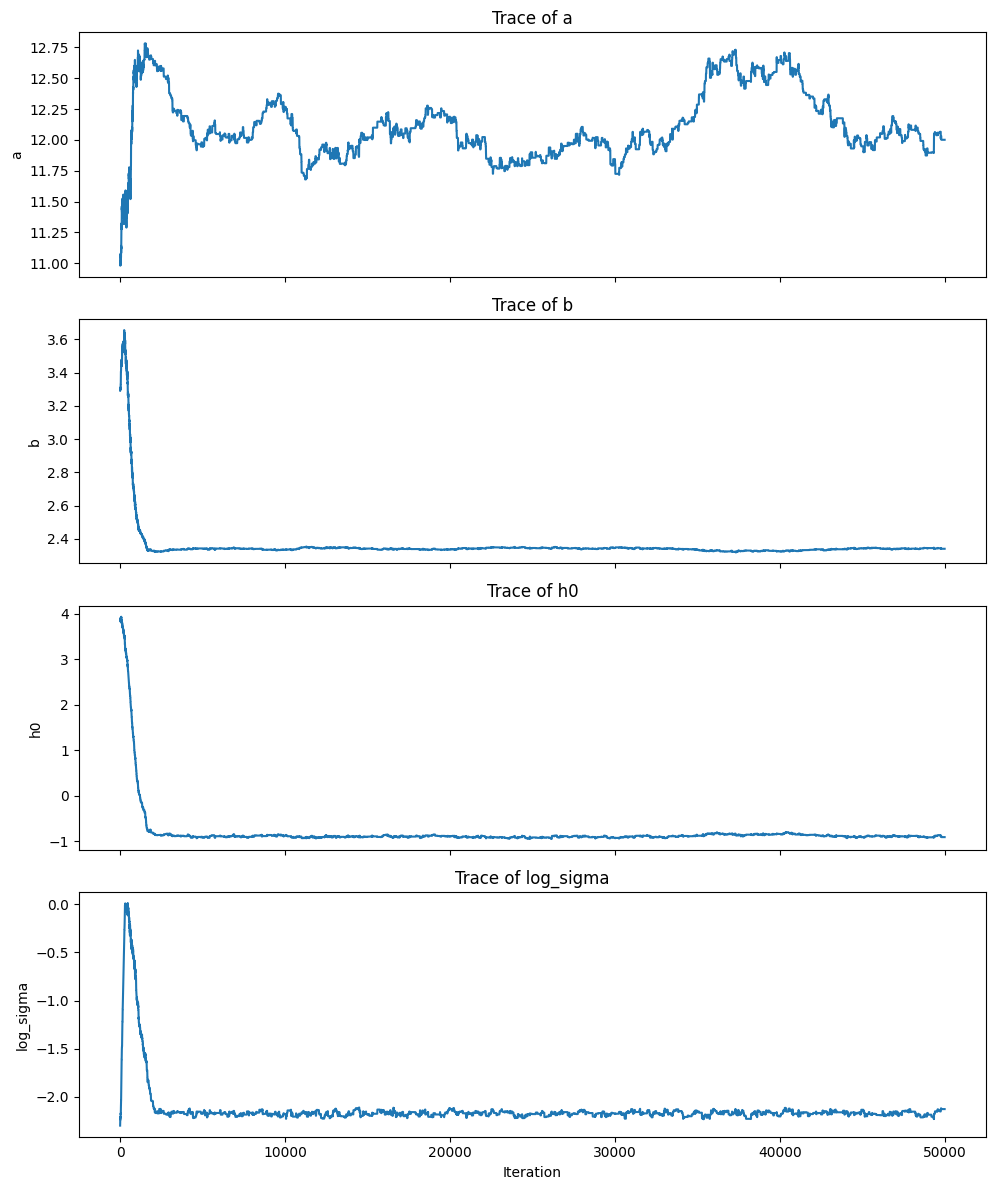

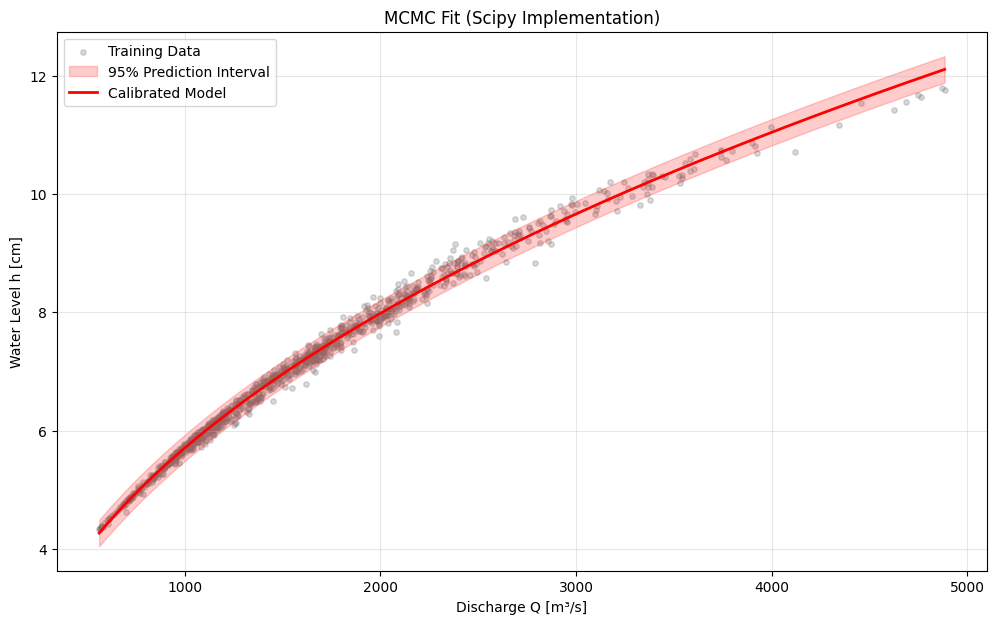

In [52]:
# --- 2. Setup MCMC Initialization ---

min_h = np.min(h_combined)
initial_h0 = min_h - 0.5

# Starting Guesses
initial_theta = np.array([prior_mu_a +1, prior_mu_b +1, initial_h0, prior_mu_log_sigma]) # Start at Prior Means

# Multivariate Proposal
raw_step_sizes = np.array([0.03, 0.015, 0.015, 0.02])
cov_prop = np.diag(raw_step_sizes**2)
mu_prop = np.zeros(4)

# MCMC Settings
n_iterations = 50000
burn_in = 5000 

chain = np.zeros((n_iterations, 4))
chain[0] = initial_theta
current_log_post = log_posterior(initial_theta, Q_combined, h_combined)

accepted = 0

# --- 3. Run MCMC Loop ---

print("Starting MCMC using Scipy Stats...")

for i in range(1, n_iterations):
    
    # A. Propose new parameter set
    perturbation = stats.multivariate_normal.rvs(mean=mu_prop, cov=cov_prop)
    proposal = chain[i-1] + perturbation
    
    # B. Calculate Posterior
    proposal_log_post = log_posterior(proposal, Q_combined, h_combined)
    
    # C. Calculate Acceptance Probability
    log_alpha = proposal_log_post - current_log_post
    
    # D. Accept or Reject
    if np.log(np.random.rand()) < log_alpha:
        chain[i] = proposal
        current_log_post = proposal_log_post
        accepted += 1
    else:
        chain[i] = chain[i-1]
        
    if i % 2000 == 0:
        print(f"Iteration {i}/{n_iterations} | Acceptance Rate: {accepted/i:.2%}")

print("MCMC Finished.")

# --- 4. Analysis and Plotting ---

samples = chain[burn_in:]

a_est = np.mean(samples[:, 0])
b_est = np.mean(samples[:, 1])
h0_est = np.mean(samples[:, 2])
sigma_est = np.mean(np.exp(samples[:, 3]))

print("\n--- Calibrated Parameters ---")
print(f"a  (Scale) : {a_est:.4f}")
print(f"b  (Shape) : {b_est:.4f}")
print(f"h0 (Offset): {h0_est:.4f}")
print(f"sigma (Err): {sigma_est:.4f}")
print(f"Acceptance Rate: {accepted/n_iterations:.2%}")

# Plot Traceplots
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
param_names = ['a', 'b', 'h0', 'log_sigma']

for j, ax in enumerate(axes):
    ax.plot(chain[:, j])
    ax.set_ylabel(param_names[j])
    ax.set_title(f"Trace of {param_names[j]}")

plt.xlabel("Iteration")
plt.tight_layout()
plt.show()

# Plot Model Fit
plt.figure(figsize=(12, 7))
plt.scatter(Q_combined, h_combined, alpha=0.3, label='Training Data', color='gray', s=15)

# Generate Model Curve
Q_range = np.linspace(np.min(Q_combined), np.max(Q_combined), 200)
h_mean_fit = stage_discharge_model(Q_range, a_est, b_est, h0_est)

upper_bound = h_mean_fit + 1.96 * sigma_est
lower_bound = h_mean_fit - 1.96 * sigma_est

plt.fill_between(Q_range, lower_bound, upper_bound, color='red', alpha=0.2, label='95% Prediction Interval')
plt.plot(Q_range, h_mean_fit, color='red', linewidth=2, label='Calibrated Model')

plt.xlabel("Discharge Q [m³/s]")
plt.ylabel("Water Level h [cm]")
plt.title(f"MCMC Fit (Scipy Implementation)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Same as above but with different step size

Starting MCMC using Scipy Stats...
Acceptance rate too high (44.00%), increasing step size.
Acceptance rate too high (37.50%), increasing step size.
Acceptance rate too high (34.33%), increasing step size.
Acceptance rate too high (31.25%), increasing step size.
Acceptance rate too high (29.00%), increasing step size.
Acceptance rate too high (26.17%), increasing step size.
Acceptance rate too high (23.29%), increasing step size.
Acceptance rate too high (21.00%), increasing step size.
Acceptance rate too low (18.67%), reducing step size.
Acceptance rate too low (17.10%), reducing step size.
Acceptance rate too low (15.91%), reducing step size.
Acceptance rate too low (14.67%), reducing step size.
Acceptance rate too low (13.54%), reducing step size.
Acceptance rate too low (12.57%), reducing step size.
Acceptance rate too low (11.80%), reducing step size.
Acceptance rate too low (11.06%), reducing step size.
Acceptance rate too low (10.47%), reducing step size.
Acceptance rate too low

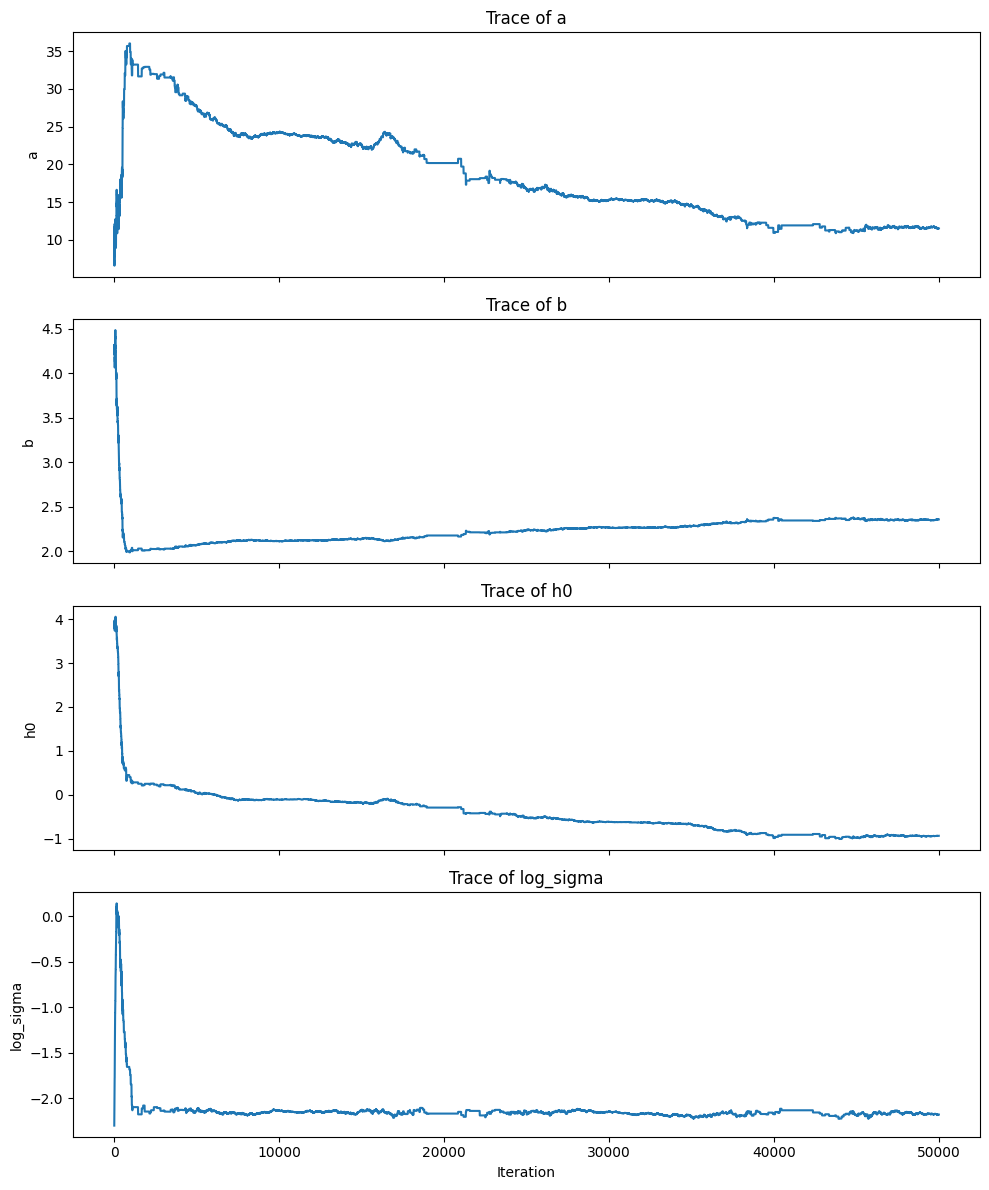

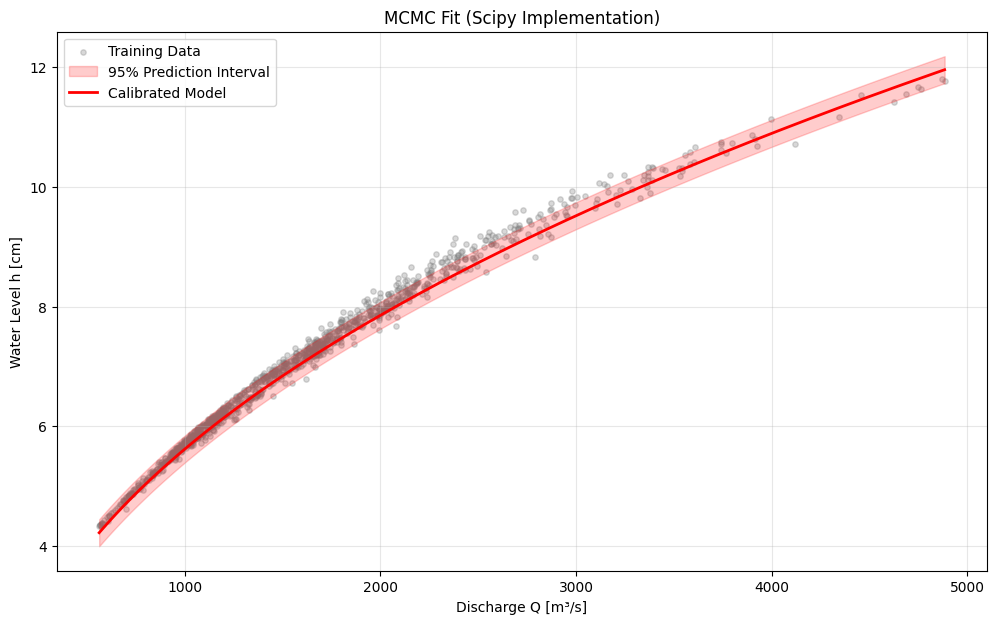

In [53]:
# --- 2. Setup MCMC Initialization ---

# Starting Guesses
initial_theta = np.array([prior_mu_a +2, prior_mu_b +2, initial_h0, prior_mu_log_sigma]) # Start at Prior Means

# Multivariate Proposal
raw_step_sizes = np.array([1, 0.05, 0.05, 0.05]) # Adjusted step sizes for new scales
cov_prop = np.diag(raw_step_sizes**2)
mu_prop = np.zeros(4)

# MCMC Settings
n_iterations = 50000
burn_in = 10000

chain = np.zeros((n_iterations, 4))
chain[0] = initial_theta
current_log_post = log_posterior(initial_theta, Q_combined, h_combined)

accepted = 0
target_acceptance_rate = 0.2  # Target acceptance rate (e.g., 20%)

# --- 3. Run MCMC Loop ---
print("Starting MCMC using Scipy Stats...")

for i in range(1, n_iterations):
    
    # A. Propose new parameter set
    perturbation = stats.multivariate_normal.rvs(mean=mu_prop, cov=cov_prop)
    proposal = chain[i-1] + perturbation
    
    # B. Calculate Posterior
    proposal_log_post = log_posterior(proposal, Q_combined, h_combined)
    
    # C. Calculate Acceptance Probability
    log_alpha = proposal_log_post - current_log_post
    
    # D. Accept or Reject the proposal
    if np.log(np.random.rand()) < log_alpha:
        chain[i] = proposal
        current_log_post = proposal_log_post
        accepted += 1
    else:
        chain[i] = chain[i-1]  # Keep the previous sample if rejected
    
    # E. Adjust proposal distribution based on acceptance rate
    if i % 100 == 0:  # Adjust every 100 iterations
        acceptance_rate = accepted / i  # Calculate the current acceptance rate
        
        # If acceptance rate is too low, reduce the step size
        if acceptance_rate < target_acceptance_rate:
            print(f"Acceptance rate too low ({acceptance_rate:.2%}), reducing step size.")
            cov_prop *= 0.9  # Reduce step size (shrink the covariance matrix)
        
        # If acceptance rate is too high, increase the step size
        elif acceptance_rate > target_acceptance_rate:
            print(f"Acceptance rate too high ({acceptance_rate:.2%}), increasing step size.")
            cov_prop *= 1.1  # Increase step size (expand the covariance matrix)
    
    # Print progress every 2000 iterations
    if i % 2000 == 0:
        print(f"Iteration {i}/{n_iterations} | Acceptance Rate: {accepted/i:.2%}")

print("MCMC Finished.")

# --- 4. Analysis and Plotting ---

samples = chain[burn_in:]

a_est = np.mean(samples[:, 0])
b_est = np.mean(samples[:, 1])
h0_est = np.mean(samples[:, 2])
sigma_est = np.exp(np.mean(samples[:, 3]))

print("\n--- Calibrated Parameters ---")
print(f"a  (Scale) : {a_est:.4f}")
print(f"b  (Shape) : {b_est:.4f}")
print(f"h0 (Offset): {h0_est:.4f}")
print(f"sigma (Err): {sigma_est:.4f}")
print(f"Acceptance Rate: {accepted/n_iterations:.2%}")

# Plot Traceplots
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
param_names = ['a', 'b', 'h0', 'log_sigma']

for j, ax in enumerate(axes):
    ax.plot(chain[:, j])
    ax.set_ylabel(param_names[j])
    ax.set_title(f"Trace of {param_names[j]}")

plt.xlabel("Iteration")
plt.tight_layout()
plt.show()

# Plot Model Fit
plt.figure(figsize=(12, 7))
plt.scatter(Q_combined, h_combined, alpha=0.3, label='Training Data', color='gray', s=15)

# Generate Model Curve
Q_range = np.linspace(np.min(Q_combined), np.max(Q_combined), 200)
h_mean_fit = stage_discharge_model(Q_range, a_est, b_est, h0_est)

upper_bound = h_mean_fit + 1.96 * sigma_est
lower_bound = h_mean_fit - 1.96 * sigma_est

plt.fill_between(Q_range, lower_bound, upper_bound, color='red', alpha=0.2, label='95% Prediction Interval')
plt.plot(Q_range, h_mean_fit, color='red', linewidth=2, label='Calibrated Model')

plt.xlabel("Discharge Q [m³/s]")
plt.ylabel("Water Level h [cm]")
plt.title(f"MCMC Fit (Scipy Implementation)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### New model 4 Chains

#### Step sizes (Standard Deviations)
step_sizes = np.array([0.005, 0.005, 2.5, 0.1]) 

#### Base guess for parameters [a, b, h0, log_sigma]
base_theta = np.array([0.08, 1.8, -2.0, 0.2])

In [54]:
# Define model and likelihood functions
def log_likelihood(theta, Q_data, h_data):
    a, b, h0, log_sigma = theta
    sigma = np.exp(log_sigma)
    if (not np.isfinite(sigma)) or (sigma <= 0):
        return -np.inf

    h_model = stage_discharge_model(Q_data, a, b, h0)
    residuals = h_data - h_model
    # Gaussian Log-Likelihood
    n = len(h_data)
    log_lik = -n * log_sigma - 0.5 * n * np.log(2 * np.pi) - 0.5 * np.sum((residuals / sigma)**2)
    
    return log_lik

def run_mcmc_chain(chain_id, n_iterations, initial_theta, step_sizes, Q_data, h_data):
    """
    Runs a single MCMC chain starting at initial_theta.
    """
    # Initialize storage
    chain = np.zeros((n_iterations, 4))
    chain[0] = initial_theta
    
    # Proposal distribution
    mu_prop = np.zeros(4)
    cov_prop = np.diag(step_sizes**2)
    
    current_log_post = log_posterior(initial_theta, Q_data, h_data)
    accepted = 0
    
    print(f"Chain {chain_id} started at: {np.round(initial_theta, 3)}")

    for i in range(1, n_iterations):
        
        # A. Propose new parameter set
        perturbation = stats.multivariate_normal.rvs(mean=mu_prop, cov=cov_prop)
        proposal = chain[i-1] + perturbation
        
        # B. Calculate Posterior
        proposal_log_post = log_posterior(proposal, Q_data, h_data)
        
        # C. Acceptance Probability
        log_alpha = proposal_log_post - current_log_post
        
        # D. Accept or Reject
        if np.log(np.random.rand()) < log_alpha:
            chain[i] = proposal
            current_log_post = proposal_log_post
            accepted += 1
        else:
            chain[i] = chain[i-1]
            
    # Calculate acceptance rate
    acc_rate = accepted / (n_iterations - 1)
    print(f"Chain {chain_id} Finished | Acceptance Rate: {acc_rate:.2%}")
    
    return chain

def calculate_r_hat(chains):
    """
    Computes the R_hat statistic for convergence.
    Input: chains array of shape (n_chains, n_samples, n_params)
    """
    M, N, P = chains.shape # M chains, N samples, P parameters
    
    # 1. Mean of each chain
    theta_bar_m = np.mean(chains, axis=1) # Shape (M, P)
    
    # 2. Within-chain variance (W)
    s_squared_m = np.var(chains, axis=1, ddof=1)
    W = np.mean(s_squared_m, axis=0) 
    
    # 3. Grand mean
    theta_bar_all = np.mean(theta_bar_m, axis=0)
    
    # 4. Between-chain variance (B)
    B = (N / (M - 1)) * np.sum((theta_bar_m - theta_bar_all)**2, axis=0)
    
    # 5. R_hat
    Var_hat = ((N - 1) / N) * W + (1 / N) * B
    R_hat = np.sqrt(Var_hat / W)
    
    return R_hat


--- Starting 4 MCMC Chains ---
Chain 1 started at: [ 9.993  2.49  -3.298 -0.258]
Chain 1 Finished | Acceptance Rate: 3.31%
Chain 2 started at: [10.017  2.475  3.18  -0.52 ]
Chain 2 Finished | Acceptance Rate: 3.73%
Chain 3 started at: [ 9.987  2.642 -9.804  0.245]
Chain 3 Finished | Acceptance Rate: 4.35%
Chain 4 started at: [9.992 2.626 2.997 0.122]
Chain 4 Finished | Acceptance Rate: 3.63%

--- Gelman-Rubin Convergence Diagnostics ---
Target: R_hat < 1.05
a          : 3.22145  [NOT CONVERGED]
b          : 3.21111  [NOT CONVERGED]
h0         : 3.04395  [NOT CONVERGED]
log_sigma  : 1.00083  [CONVERGED]

--- Final Calibrated Parameters ---
a  : 9.1853
b  : 2.4281
h0 : -1.2037
sigma : 0.1132


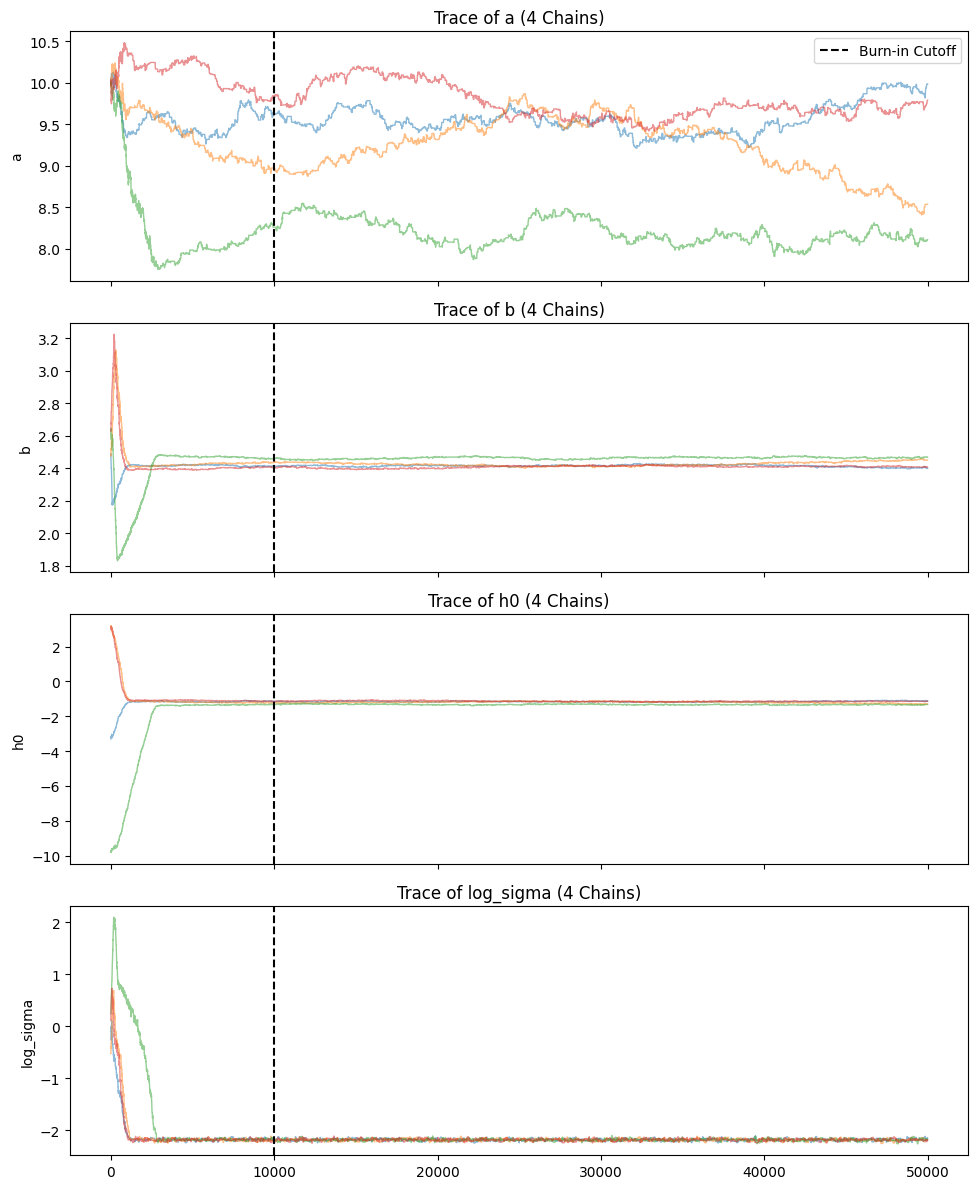

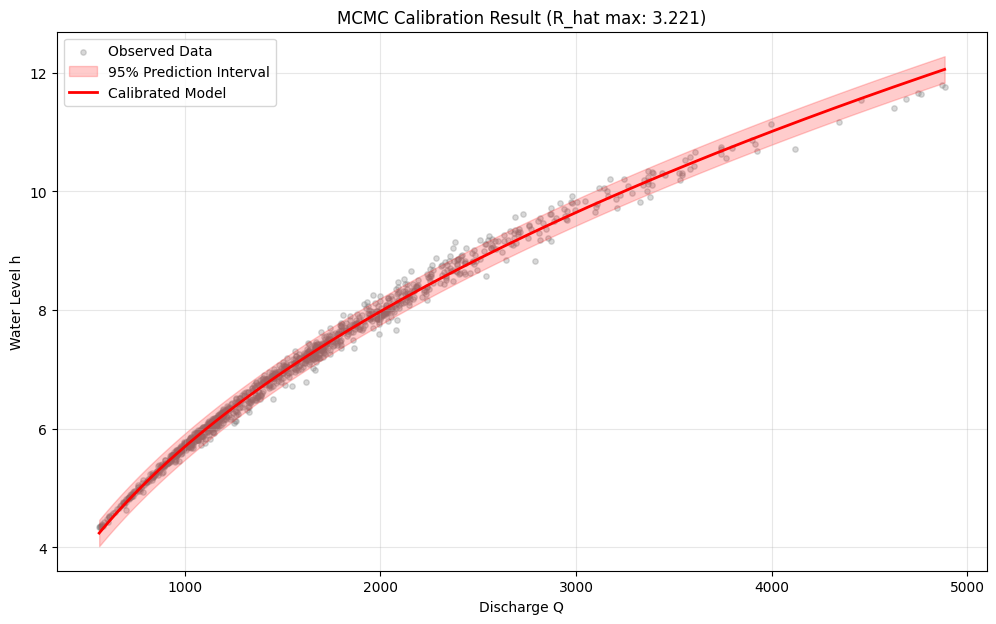

In [57]:
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Settings
n_chains = 4
n_iterations = 50000
burn_in = 10000

# Step sizes (Standard Deviations)
step_sizes = np.array([0.02, 0.01, 0.02, 0.03])

# Base guess for parameters [a, b, h0, log_sigma]
base_theta = np.array([10, 2.5, -2, 0])

# Storage for results
all_chains_full = [] # To store full history for plotting
all_chains_burned = [] # To store only valid samples for statistics

# 2. Run Multiple Chains
print(f"--- Starting {n_chains} MCMC Chains ---")

for i in range(n_chains):
    # randomize starting point slightly for each chain
    noise = np.random.normal(0, 1, 4) * np.array([0.02, 0.2, 5.0, 0.5])
    start_theta = base_theta + noise
    
    # Ensure h0 is reasonable (negative)
    start_theta[0] = abs(start_theta[0])            # a > 0
    start_theta[1] = abs(start_theta[1])            # b > 0
    start_theta[2] = min_h - abs(start_theta[2]) - 1e-3
     
    # Run
    chain_res = run_mcmc_chain(i+1, n_iterations, start_theta, step_sizes, Q_combined, h_combined)
    
    all_chains_full.append(chain_res)
    all_chains_burned.append(chain_res[burn_in:])

# Convert to 3D Arrays
chains_burned_array = np.array(all_chains_burned) # Shape (4, 30000, 4)
chains_full_array = np.array(all_chains_full)     # Shape (4, 50000, 4)

# 3. Calculate Gelman-Rubin R_hat
r_hat_values = calculate_r_hat(chains_burned_array)
param_labels = ['a', 'b', 'h0', 'log_sigma']

print("\n--- Gelman-Rubin Convergence Diagnostics ---")
print("Target: R_hat < 1.05")
for name, r_val in zip(param_labels, r_hat_values):
    status = "CONVERGED" if r_val < 1.05 else "NOT CONVERGED"
    print(f"{name:10} : {r_val:.5f}  [{status}]")

# 4. Calculate Final Estimates (Combine all chains)
# Flatten the 4 chains into one giant list of samples
combined_samples = chains_burned_array.reshape(-1, 4)

a_est = np.mean(combined_samples[:, 0])
b_est = np.mean(combined_samples[:, 1])
h0_est = np.mean(combined_samples[:, 2])
sigma_est = np.mean(np.exp(combined_samples[:, 3]))

print("\n--- Final Calibrated Parameters ---")
print(f"a  : {a_est:.4f}")
print(f"b  : {b_est:.4f}")
print(f"h0 : {h0_est:.4f}")
print(f"sigma : {sigma_est:.4f}")

# 5. Visualizations
# A. Trace Plots (Show all 4 chains)
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Blue, Orange, Green, Red

for j, ax in enumerate(axes):
    for c in range(n_chains):
        # Plot full history to see the start point
        ax.plot(chains_full_array[c, :, j], color=colors[c], alpha=0.5, linewidth=1)
    
    ax.axvline(burn_in, color='black', linestyle='--', label='Burn-in Cutoff')
    ax.set_ylabel(param_labels[j])
    ax.set_title(f"Trace of {param_labels[j]} (4 Chains)")
    if j==0: ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# B. Model Fit
plt.figure(figsize=(12, 7))
plt.scatter(Q_combined, h_combined, alpha=0.3, label='Observed Data', color='gray', s=15)

# Generate Model Curve
Q_range = np.linspace(np.min(Q_combined), np.max(Q_combined), 200)
h_mean_fit = stage_discharge_model(Q_range, a_est, b_est, h0_est)

# Prediction Intervals
upper_bound = h_mean_fit + 1.96 * sigma_est
lower_bound = h_mean_fit - 1.96 * sigma_est

plt.fill_between(Q_range, lower_bound, upper_bound, color='red', alpha=0.2, label='95% Prediction Interval')
plt.plot(Q_range, h_mean_fit, color='red', linewidth=2, label='Calibrated Model')

plt.xlabel("Discharge Q")
plt.ylabel("Water Level h")
plt.title(f"MCMC Calibration Result (R_hat max: {np.max(r_hat_values):.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Step sizes (Standard Deviations)
step_sizes = np.array([0.005, 0.005, 2.5, 0.1]) 

#### Base guess for parameters [a, b, h0, log_sigma]
base_theta = np.array([0.08, 1.8, -2.0, 0.2])

--- Starting 4 MCMC Chains ---
Chain 1 started at: [ 0.105  1.594 -2.632  0.435]
Chain 1 Finished | Acceptance Rate: 1.01%
Chain 2 started at: [ 0.098  2.134 -0.349  0.131]
Chain 2 Finished | Acceptance Rate: 0.72%
Chain 3 started at: [ 0.083  1.765 -3.621  0.614]
Chain 3 Finished | Acceptance Rate: 0.95%
Chain 4 started at: [ 0.054  1.865 -0.003  0.052]
Chain 4 Finished | Acceptance Rate: 0.93%

--- Gelman-Rubin Convergence Diagnostics ---
Target: R_hat < 1.05
a          : 18.03443  [NOT CONVERGED]
b          : 11.77397  [NOT CONVERGED]
h0         : 6.54068  [NOT CONVERGED]
log_sigma  : 1.03059  [CONVERGED]

--- Final Calibrated Parameters ---
a  : 0.7611
b  : 3.1877
h0 : -3.8340
sigma : 0.1182


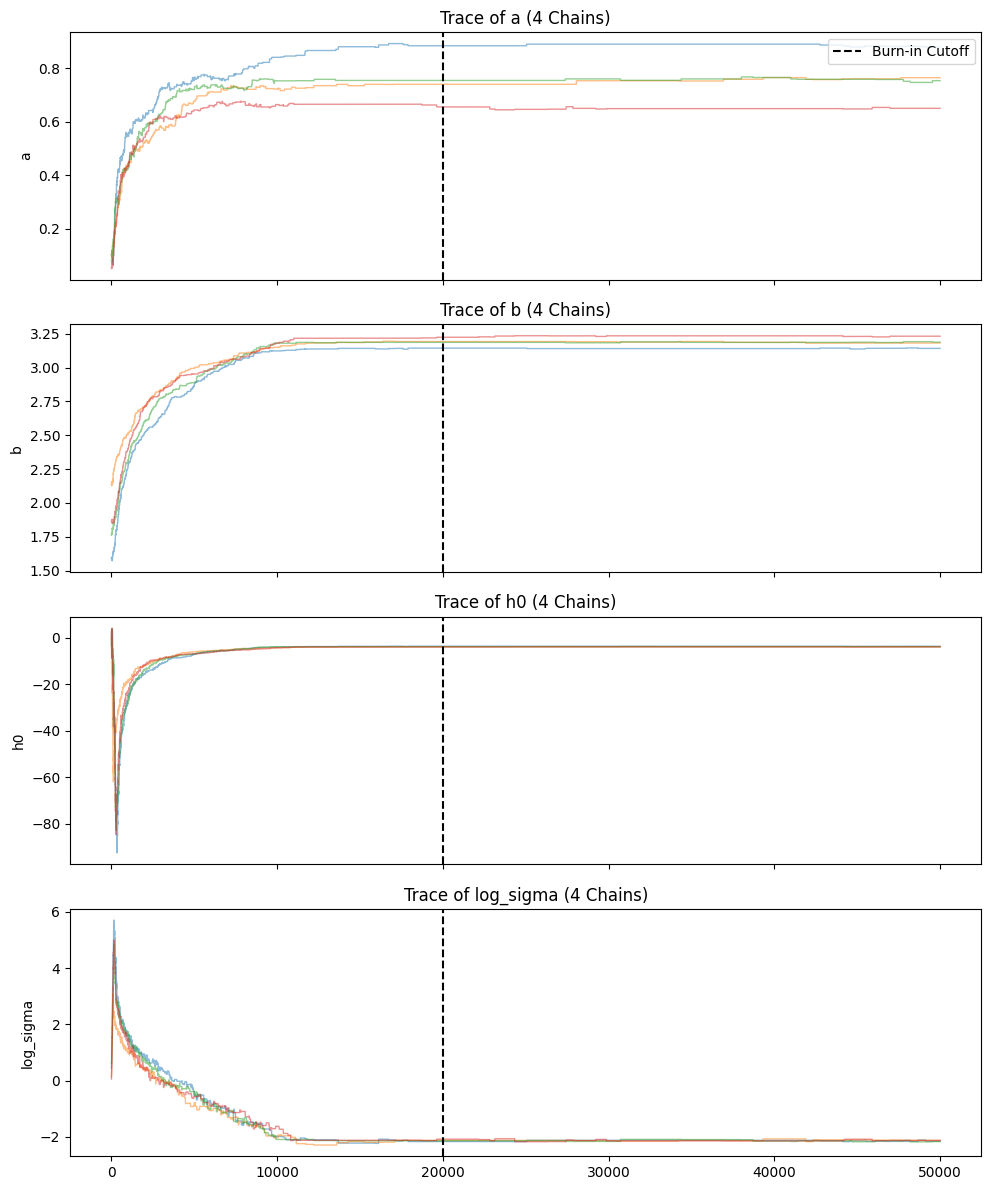

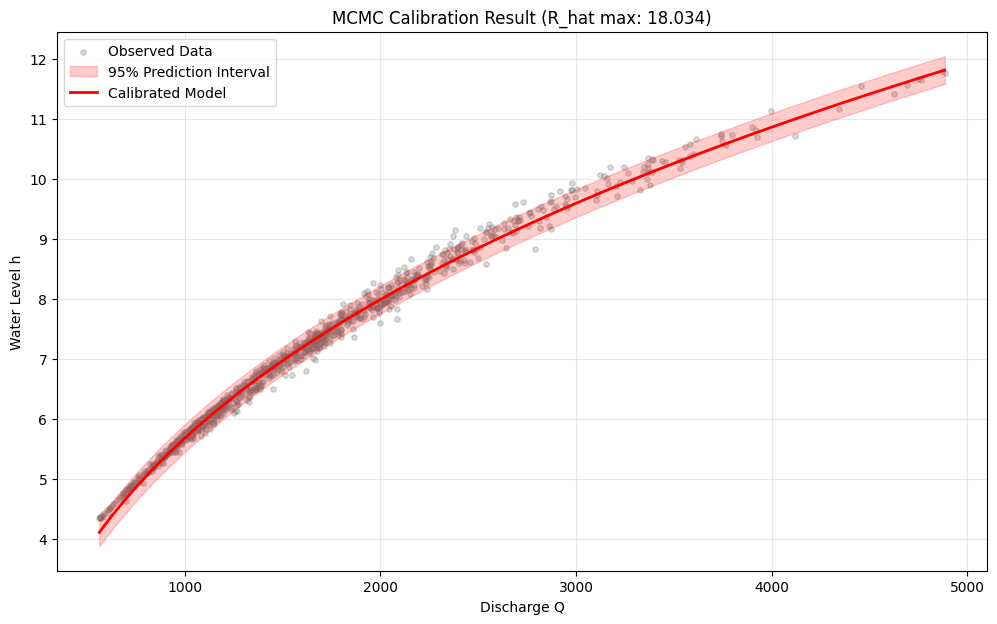

In [13]:
# Define model and likelihood functions
def stage_discharge_model(Q, a, b, h0):
    # h = h0 + (Q/a)^(1/b)
    return h0 + np.power((Q/a), 1.0/b)

def log_prior(theta, h_data):
    # Uninformative (Uniform) Priors
    a, b, h0, log_sigma = theta

    if a <= 0 or b <= 0:
        return -np.inf
    
    # Physical constraint: h0 (bed level) must be below lowest observed water level
    min_h = np.min(h_data) 
    if h0 >= min_h: 
        return -np.inf

    return 0.0
    
def log_likelihood(theta, Q_data, h_data):
    a, b, h0, log_sigma = theta
    sigma = np.exp(log_sigma)

    h_model = stage_discharge_model(Q_data, a, b, h0)
    residuals = h_data - h_model
    # Gaussian Log-Likelihood
    n = len(h_data)
    log_lik = -n * log_sigma - 0.5 * n * np.log(2 * np.pi) - 0.5 * np.sum((residuals / sigma)**2)
    
    return log_lik

def log_posterior(theta, Q_data, h_data):
    lp = log_prior(theta, h_data)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, Q_data, h_data)

def run_mcmc_chain(chain_id, n_iterations, initial_theta, step_sizes, Q_data, h_data):
    """
    Runs a single MCMC chain starting at initial_theta.
    """
    # Initialize storage
    chain = np.zeros((n_iterations, 4))
    chain[0] = initial_theta
    
    # Proposal distribution
    mu_prop = np.zeros(4)
    cov_prop = np.diag(step_sizes**2)
    
    current_log_post = log_posterior(initial_theta, Q_data, h_data)
    accepted = 0
    
    print(f"Chain {chain_id} started at: {np.round(initial_theta, 3)}")

    for i in range(1, n_iterations):
        
        # A. Propose new parameter set
        perturbation = stats.multivariate_normal.rvs(mean=mu_prop, cov=cov_prop)
        proposal = chain[i-1] + perturbation
        
        # B. Calculate Posterior
        proposal_log_post = log_posterior(proposal, Q_data, h_data)
        
        # C. Acceptance Probability
        log_alpha = proposal_log_post - current_log_post
        
        # D. Accept or Reject
        if np.log(np.random.rand()) < log_alpha:
            chain[i] = proposal
            current_log_post = proposal_log_post
            accepted += 1
        else:
            chain[i] = chain[i-1]
            
    # Calculate acceptance rate
    acc_rate = accepted / n_iterations
    print(f"Chain {chain_id} Finished | Acceptance Rate: {acc_rate:.2%}")
    
    return chain

def calculate_r_hat(chains):
    """
    Computes the R_hat statistic for convergence.
    Input: chains array of shape (n_chains, n_samples, n_params)
    """
    M, N, P = chains.shape # M chains, N samples, P parameters
    
    # 1. Mean of each chain
    theta_bar_m = np.mean(chains, axis=1) # Shape (M, P)
    
    # 2. Within-chain variance (W)
    s_squared_m = np.var(chains, axis=1, ddof=1)
    W = np.mean(s_squared_m, axis=0) 
    
    # 3. Grand mean
    theta_bar_all = np.mean(theta_bar_m, axis=0)
    
    # 4. Between-chain variance (B)
    B = (N / (M - 1)) * np.sum((theta_bar_m - theta_bar_all)**2, axis=0)
    
    # 5. R_hat
    Var_hat = ((N - 1) / N) * W + (1 / N) * B
    R_hat = np.sqrt(Var_hat / W)
    
    return R_hat

#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Settings
n_chains = 4
n_iterations = 50000
burn_in = 20000

# Step sizes (Standard Deviations)
step_sizes = np.array([0.005, 0.005, 2.5, 0.1]) 

# Base guess for parameters [a, b, h0, log_sigma]
base_theta = np.array([0.08, 1.8, -2.0, 0.2])

# Storage for results
all_chains_full = [] # To store full history for plotting
all_chains_burned = [] # To store only valid samples for statistics

# 2. Run Multiple Chains
print(f"--- Starting {n_chains} MCMC Chains ---")

for i in range(n_chains):
    # randomize starting point slightly for each chain
    noise = np.random.normal(0, 1, 4) * np.array([0.02, 0.2, 5.0, 0.5])
    start_theta = np.abs(base_theta + noise)
    
    # Ensure h0 is reasonable (negative)
    start_theta[2] = -np.abs(start_theta[2]) 
    
    # Run
    chain_res = run_mcmc_chain(i+1, n_iterations, start_theta, step_sizes, Q_combined, h_combined)
    
    all_chains_full.append(chain_res)
    all_chains_burned.append(chain_res[burn_in:])

# Convert to 3D Arrays
chains_burned_array = np.array(all_chains_burned) # Shape (4, 30000, 4)
chains_full_array = np.array(all_chains_full)     # Shape (4, 50000, 4)

# 3. Calculate Gelman-Rubin R_hat
r_hat_values = calculate_r_hat(chains_burned_array)
param_labels = ['a', 'b', 'h0', 'log_sigma']

print("\n--- Gelman-Rubin Convergence Diagnostics ---")
print("Target: R_hat < 1.05")
for name, r_val in zip(param_labels, r_hat_values):
    status = "CONVERGED" if r_val < 1.05 else "NOT CONVERGED"
    print(f"{name:10} : {r_val:.5f}  [{status}]")

# 4. Calculate Final Estimates (Combine all chains)
# Flatten the 4 chains into one giant list of samples
combined_samples = chains_burned_array.reshape(-1, 4)

a_est = np.mean(combined_samples[:, 0])
b_est = np.mean(combined_samples[:, 1])
h0_est = np.mean(combined_samples[:, 2])
sigma_est = np.exp(np.mean(combined_samples[:, 3]))

print("\n--- Final Calibrated Parameters ---")
print(f"a  : {a_est:.4f}")
print(f"b  : {b_est:.4f}")
print(f"h0 : {h0_est:.4f}")
print(f"sigma : {sigma_est:.4f}")

# 5. Visualizations
# A. Trace Plots (Show all 4 chains)
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Blue, Orange, Green, Red

for j, ax in enumerate(axes):
    for c in range(n_chains):
        # Plot full history to see the start point
        ax.plot(chains_full_array[c, :, j], color=colors[c], alpha=0.5, linewidth=1)
    
    ax.axvline(burn_in, color='black', linestyle='--', label='Burn-in Cutoff')
    ax.set_ylabel(param_labels[j])
    ax.set_title(f"Trace of {param_labels[j]} (4 Chains)")
    if j==0: ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# B. Model Fit
plt.figure(figsize=(12, 7))
plt.scatter(Q_combined, h_combined, alpha=0.3, label='Observed Data', color='gray', s=15)

# Generate Model Curve
Q_range = np.linspace(np.min(Q_combined), np.max(Q_combined), 200)
h_mean_fit = stage_discharge_model(Q_range, a_est, b_est, h0_est)

# Prediction Intervals
upper_bound = h_mean_fit + 1.96 * sigma_est
lower_bound = h_mean_fit - 1.96 * sigma_est

plt.fill_between(Q_range, lower_bound, upper_bound, color='red', alpha=0.2, label='95% Prediction Interval')
plt.plot(Q_range, h_mean_fit, color='red', linewidth=2, label='Calibrated Model')

plt.xlabel("Discharge Q")
plt.ylabel("Water Level h")
plt.title(f"MCMC Calibration Result (R_hat max: {np.max(r_hat_values):.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Starting 4 MCMC Chains (Units: Meters) ---
Chain 1 started at: [49.4787  2.3949 -2.236   2.664 ]
Chain 1 Finished | Acceptance Rate: 0.21%
Chain 2 started at: [59.4883  2.3863 -2.002   3.2444]
Chain 2 Finished | Acceptance Rate: 0.21%
Chain 3 started at: [35.1983  2.3547 -2.0052  2.9069]
Chain 3 Finished | Acceptance Rate: 0.18%
Chain 4 started at: [45.4314  2.2727 -1.8452  2.8923]
Chain 4 Finished | Acceptance Rate: 0.15%

--- Gelman-Rubin Convergence Diagnostics ---
Target: R_hat < 1.05
a          : 5.04845  [NOT CONVERGED]
b          : 5.44021  [NOT CONVERGED]
h0         : 5.83150  [NOT CONVERGED]
log_sigma  : 1.34721  [NOT CONVERGED]

--- Final Calibrated Parameters ---
a      : 5.1298
b      : 2.6149
h0     : -1.8622 m
sigma  : 0.1139 m


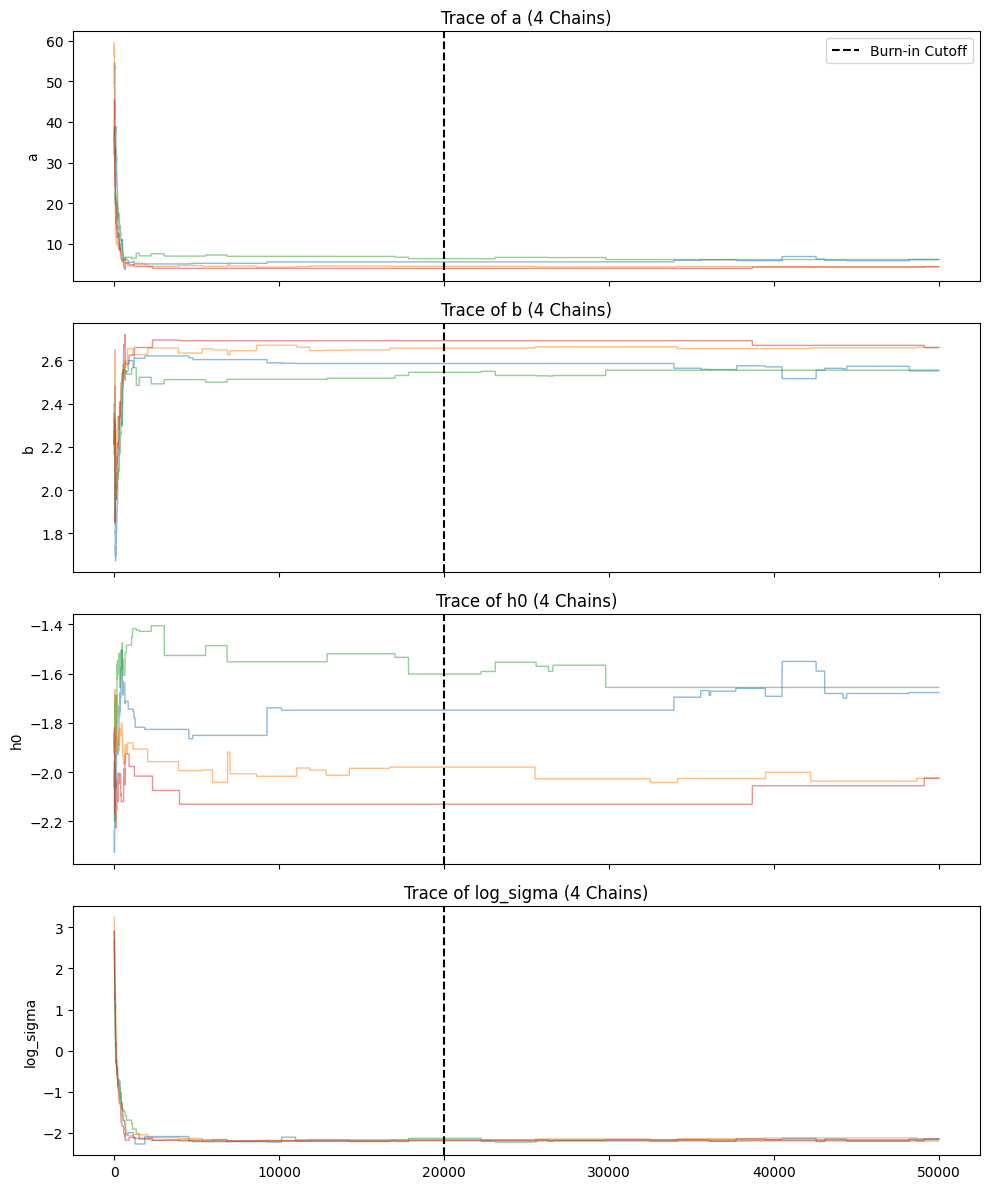

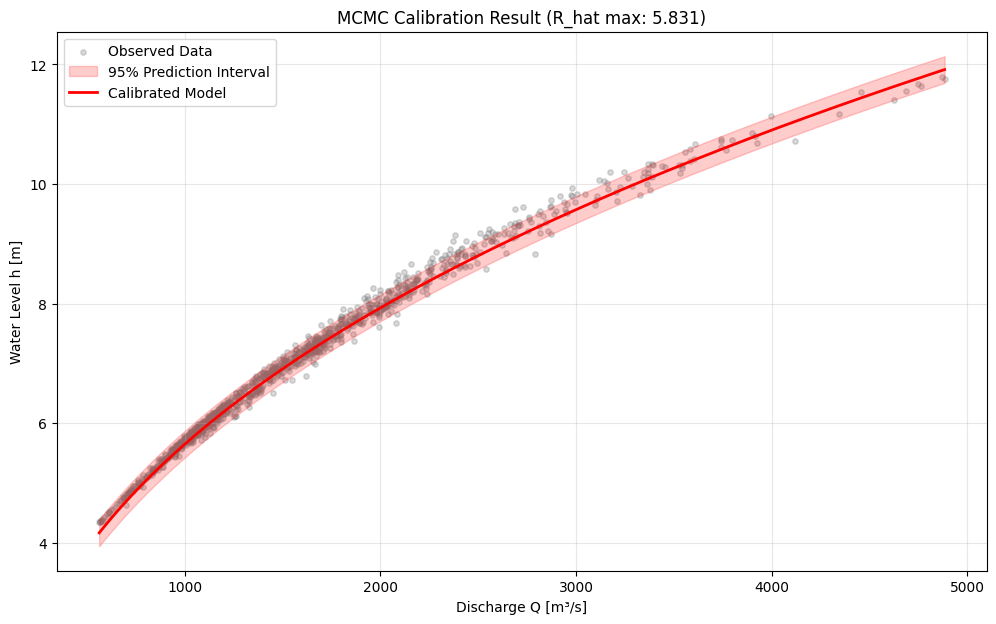

In [14]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# ==========================================
# PART 1: MODEL DEFINITIONS
# ==========================================

def stage_discharge_model(Q, a, b, h0):
    # h = h0 + (Q/a)^(1/b)
    # Safety check: ensure Q/a is non-negative
    term = np.maximum(Q / a, 0)
    return h0 + np.power(term, 1.0/b)

def log_prior(theta, h_data, settings):
    """
    UPDATED: Takes 'settings' dictionary as input for Prior Hyperparameters.
    """
    a, b, h0, log_sigma = theta

    # 1. GATEKEEPERS: Hard Constraints
    if a <= 0 or b <= 0:
        return -np.inf
    
    # Bed level must be below lowest water level
    min_h = np.min(h_data) 
    if h0 >= min_h: 
        return -np.inf

    # 2. INFORMATIVE PRIORS (Gaussian)
    # Values are now unpacked from the 'settings' dictionary
    
    # Prior for b (Shape)
    lp_b = stats.norm.logpdf(b, loc=settings['mu_b'], scale=settings['std_b'])
    
    # Prior for a (Conveyance)
    lp_a = stats.norm.logpdf(a, loc=settings['mu_a'], scale=settings['std_a'])
    
    # Prior for h0 (Bed Level)
    lp_h0 = stats.norm.logpdf(h0, loc=settings['mu_h0'], scale=settings['std_h0'])
    
    # Prior for log_sigma (Noise)
    lp_sigma = stats.norm.logpdf(log_sigma, loc=settings['mu_sigma'], scale=settings['std_sigma'])

    return lp_a + lp_b + lp_h0 + lp_sigma
    
def log_likelihood(theta, Q_data, h_data):
    a, b, h0, log_sigma = theta
    sigma = np.exp(log_sigma)

    h_model = stage_discharge_model(Q_data, a, b, h0)
    residuals = h_data - h_model

    n = len(h_data)
    # Gaussian Log-Likelihood
    log_lik = -n * log_sigma - 0.5 * n * np.log(2 * np.pi) - 0.5 * np.sum((residuals / sigma)**2)
    
    return log_lik

def log_posterior(theta, Q_data, h_data, settings):
    # Pass 'settings' to the prior
    lp = log_prior(theta, h_data, settings)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, Q_data, h_data)

# ==========================================
# PART 2: THE REUSABLE MCMC FUNCTION
# ==========================================

def run_mcmc_chain(chain_id, n_iterations, initial_theta, step_sizes, Q_data, h_data, settings):
    """
    Runs a single MCMC chain.
    """
    chain = np.zeros((n_iterations, 4))
    chain[0] = initial_theta
    
    # Proposal setup
    cov_prop = np.diag(step_sizes**2)
    mu_prop = np.zeros(4)
    
    # Calculate initial posterior using the settings
    current_log_post = log_posterior(initial_theta, Q_data, h_data, settings)
    accepted = 0
    
    print(f"Chain {chain_id} started at: {np.round(initial_theta, 4)}")

    for i in range(1, n_iterations):
        perturbation = stats.multivariate_normal.rvs(mean=mu_prop, cov=cov_prop)
        proposal = chain[i-1] + perturbation
        
        # Calculate new posterior using the settings
        proposal_log_post = log_posterior(proposal, Q_data, h_data, settings)
        
        log_alpha = proposal_log_post - current_log_post
        
        if np.log(np.random.rand()) < log_alpha:
            chain[i] = proposal
            current_log_post = proposal_log_post
            accepted += 1
        else:
            chain[i] = chain[i-1]
            
    print(f"Chain {chain_id} Finished | Acceptance Rate: {accepted/n_iterations:.2%}")
    return chain

def calculate_r_hat(chains):
    M, N, P = chains.shape
    theta_bar_m = np.mean(chains, axis=1)
    s_squared_m = np.var(chains, axis=1, ddof=1)
    W = np.mean(s_squared_m, axis=0) 
    theta_bar_all = np.mean(theta_bar_m, axis=0)
    B = (N / (M - 1)) * np.sum((theta_bar_m - theta_bar_all)**2, axis=0)
    Var_hat = ((N - 1) / N) * W + (1 / N) * B
    R_hat = np.sqrt(Var_hat / W)
    return R_hat

# ==========================================
# PART 3: EXECUTION
# ==========================================

# --- CONFIGURATION SETTINGS ---

# 1. MCMC Settings
n_chains = 4
n_iterations = 50000
burn_in = 20000

# 2. Prior Hyperparameters (The input for the definitions)
# Change these values here to adjust your prior beliefs
PRIOR_SETTINGS = {
    'mu_a': 40,       'std_a': 20.0,   # a: Conveyance (approx 80-120)
    'mu_b': 2.3,        'std_b': 0.5,    # b: Shape (approx 1.67)
    'mu_h0': -2.0,       'std_h0': 0.5,   # h0: Bed Level (-2.0m NAP)
    'mu_sigma': np.log(0.05), 'std_sigma': 1.0 # log_sigma: Noise (approx 5cm)
}

# 3. Step sizes (Standard Deviations for the Jumps)
step_sizes = np.array([2, 0.05, 0.05, 0.1]) 

# 4. Starting Guess
# We match the starting guess to the Mean of the Priors defined above
base_theta = np.array([
    PRIOR_SETTINGS['mu_a'], 
    PRIOR_SETTINGS['mu_b'], 
    PRIOR_SETTINGS['mu_h0'], 
    PRIOR_SETTINGS['mu_sigma']
])

# --- RUNNING THE CHAINS ---

all_chains_full = [] 
all_chains_burned = [] 

print(f"--- Starting {n_chains} MCMC Chains (Units: Meters) ---")

for i in range(n_chains):
    # Randomize starting point around the base_theta
    noise = np.random.normal(0, 1, 4) * np.array([10.0, 0.1, 0.2, 0.2])
    start_theta = np.abs(base_theta + noise)
    start_theta[2] = -np.abs(start_theta[2]) # Ensure h0 is negative
    
    # Pass PRIOR_SETTINGS into the function
    chain_res = run_mcmc_chain(i+1, n_iterations, start_theta, step_sizes, Q_combined, h_combined, PRIOR_SETTINGS)
    
    all_chains_full.append(chain_res)
    all_chains_burned.append(chain_res[burn_in:])

chains_burned_array = np.array(all_chains_burned) 
chains_full_array = np.array(all_chains_full)     

# Calculate Gelman-Rubin R_hat
r_hat_values = calculate_r_hat(chains_burned_array)
param_labels = ['a', 'b', 'h0', 'log_sigma']

print("\n--- Gelman-Rubin Convergence Diagnostics ---")
print("Target: R_hat < 1.05")
for name, r_val in zip(param_labels, r_hat_values):
    status = "CONVERGED" if r_val < 1.05 else "NOT CONVERGED"
    print(f"{name:10} : {r_val:.5f}  [{status}]")

# Final Estimates
combined_samples = chains_burned_array.reshape(-1, 4)
a_est = np.mean(combined_samples[:, 0])
b_est = np.mean(combined_samples[:, 1])
h0_est = np.mean(combined_samples[:, 2])
sigma_est = np.exp(np.mean(combined_samples[:, 3]))

print("\n--- Final Calibrated Parameters ---")
print(f"a      : {a_est:.4f}")
print(f"b      : {b_est:.4f}")
print(f"h0     : {h0_est:.4f} m")
print(f"sigma  : {sigma_est:.4f} m")

# Visualizations
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 

for j, ax in enumerate(axes):
    for c in range(n_chains):
        ax.plot(chains_full_array[c, :, j], color=colors[c], alpha=0.5, linewidth=1)
    ax.axvline(burn_in, color='black', linestyle='--', label='Burn-in Cutoff')
    ax.set_ylabel(param_labels[j])
    ax.set_title(f"Trace of {param_labels[j]} (4 Chains)")
    if j==0: ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Model Fit
plt.figure(figsize=(12, 7))
plt.scatter(Q_combined, h_combined, alpha=0.3, label='Observed Data', color='gray', s=15)

Q_range = np.linspace(np.min(Q_combined), np.max(Q_combined), 200)
h_mean_fit = stage_discharge_model(Q_range, a_est, b_est, h0_est)

upper_bound = h_mean_fit + 1.96 * sigma_est
lower_bound = h_mean_fit - 1.96 * sigma_est

plt.fill_between(Q_range, lower_bound, upper_bound, color='red', alpha=0.2, label='95% Prediction Interval')
plt.plot(Q_range, h_mean_fit, color='red', linewidth=2, label='Calibrated Model')

plt.xlabel("Discharge Q [m³/s]")
plt.ylabel("Water Level h [m]")
plt.title(f"MCMC Calibration Result (R_hat max: {np.max(r_hat_values):.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### step size changed

##### Formulas

In [15]:
# Define model and likelihood functions
def stage_discharge_model(Q, a, b, h0):
    # h = h0 + (Q/a)^(1/b)
    return h0 + np.power((Q/a), 1.0/b)

def log_prior(theta, h_data):
    # Uninformative (Uniform) Priors
    a, b, h0, log_sigma = theta

    if a <= 0 or b <= 0:
        return -np.inf
    
    # Physical constraint: h0 (bed level) must be below lowest observed water level
    min_h = np.min(h_data) 
    if h0 >= min_h: 
        return -np.inf

    return 0.0
    
def log_likelihood(theta, Q_data, h_data):
    a, b, h0, log_sigma = theta
    sigma = np.exp(log_sigma)

    h_model = stage_discharge_model(Q_data, a, b, h0)
    residuals = h_data - h_model
    # Gaussian Log-Likelihood
    n = len(h_data)
    log_lik = -n * log_sigma - 0.5 * n * np.log(2 * np.pi) - 0.5 * np.sum((residuals / sigma)**2)
    
    return log_lik

def log_posterior(theta, Q_data, h_data):
    lp = log_prior(theta, h_data)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, Q_data, h_data)

def run_mcmc_chain(chain_id, n_iterations, initial_theta, step_sizes, Q_data, h_data):
    """
    Runs a single MCMC chain starting at initial_theta.
    """
    # Initialize storage
    chain = np.zeros((n_iterations, 4))
    chain[0] = initial_theta
    
    # Proposal distribution
    mu_prop = np.zeros(4)
    cov_prop = np.diag(step_sizes**2)
    
    current_log_post = log_posterior(initial_theta, Q_data, h_data)
    accepted = 0
    
    print(f"Chain {chain_id} started at: {np.round(initial_theta, 3)}")

    for i in range(1, n_iterations):
        
        # A. Propose new parameter set
        perturbation = stats.multivariate_normal.rvs(mean=mu_prop, cov=cov_prop)
        proposal = chain[i-1] + perturbation
        
        # B. Calculate Posterior
        proposal_log_post = log_posterior(proposal, Q_data, h_data)
        
        # C. Acceptance Probability
        log_alpha = proposal_log_post - current_log_post
        
        # D. Accept or Reject
        if np.log(np.random.rand()) < log_alpha:
            chain[i] = proposal
            current_log_post = proposal_log_post
            accepted += 1
        else:
            chain[i] = chain[i-1]
            
        # E. Adjust proposal distribution based on acceptance rate
        if i % 500 == 0:  # Adjust every 500 iterations for quicker feedback
            acceptance_rate = accepted / i  # Calculate the current acceptance rate
            
            # If acceptance rate is too low, reduce the step size
            if acceptance_rate < 0.2:  # Target 20% acceptance rate
                print(f"Acceptance rate too low ({acceptance_rate:.2%}), reducing step size.")
                cov_prop *= 0.95  # Reduce step size by 5%
            
            # If acceptance rate is too high, increase the step size
            elif acceptance_rate > 0.3:  # If above 30%, increase the step size
                print(f"Acceptance rate too high ({acceptance_rate:.2%}), increasing step size.")
                cov_prop *= 1.05  # Increase step size by 5%
    
    # Calculate acceptance rate
    acc_rate = accepted / n_iterations
    print(f"Chain {chain_id} Finished | Acceptance Rate: {acc_rate:.2%}")
    
    return chain

def calculate_r_hat(chains):
    """
    Computes the R_hat statistic for convergence.
    Input: chains array of shape (n_chains, n_samples, n_params)
    """
    M, N, P = chains.shape # M chains, N samples, P parameters
    
    # 1. Mean of each chain
    theta_bar_m = np.mean(chains, axis=1) # Shape (M, P)
    
    # 2. Within-chain variance (W)
    s_squared_m = np.var(chains, axis=1, ddof=1)
    W = np.mean(s_squared_m, axis=0) 
    
    # 3. Grand mean
    theta_bar_all = np.mean(theta_bar_m, axis=0)
    
    # 4. Between-chain variance (B)
    B = (N / (M - 1)) * np.sum((theta_bar_m - theta_bar_all)**2, axis=0)
    
    # 5. R_hat
    Var_hat = ((N - 1) / N) * W + (1 / N) * B
    R_hat = np.sqrt(Var_hat / W)
    
    return R_hat

##### option 1

--- Starting 4 MCMC Chains ---
Chain 1 started at: [ 0.622  2.234 -4.844  0.196]
Acceptance rate too low (9.60%), reducing step size.
Acceptance rate too low (8.10%), reducing step size.
Acceptance rate too low (7.47%), reducing step size.
Acceptance rate too low (6.65%), reducing step size.
Acceptance rate too low (6.16%), reducing step size.
Acceptance rate too low (5.50%), reducing step size.
Acceptance rate too low (5.17%), reducing step size.
Acceptance rate too low (4.78%), reducing step size.
Acceptance rate too low (4.56%), reducing step size.
Acceptance rate too low (4.22%), reducing step size.
Acceptance rate too low (4.02%), reducing step size.
Acceptance rate too low (3.78%), reducing step size.
Acceptance rate too low (3.68%), reducing step size.
Acceptance rate too low (3.54%), reducing step size.
Acceptance rate too low (3.48%), reducing step size.
Acceptance rate too low (3.46%), reducing step size.
Acceptance rate too low (3.42%), reducing step size.
Acceptance rate to

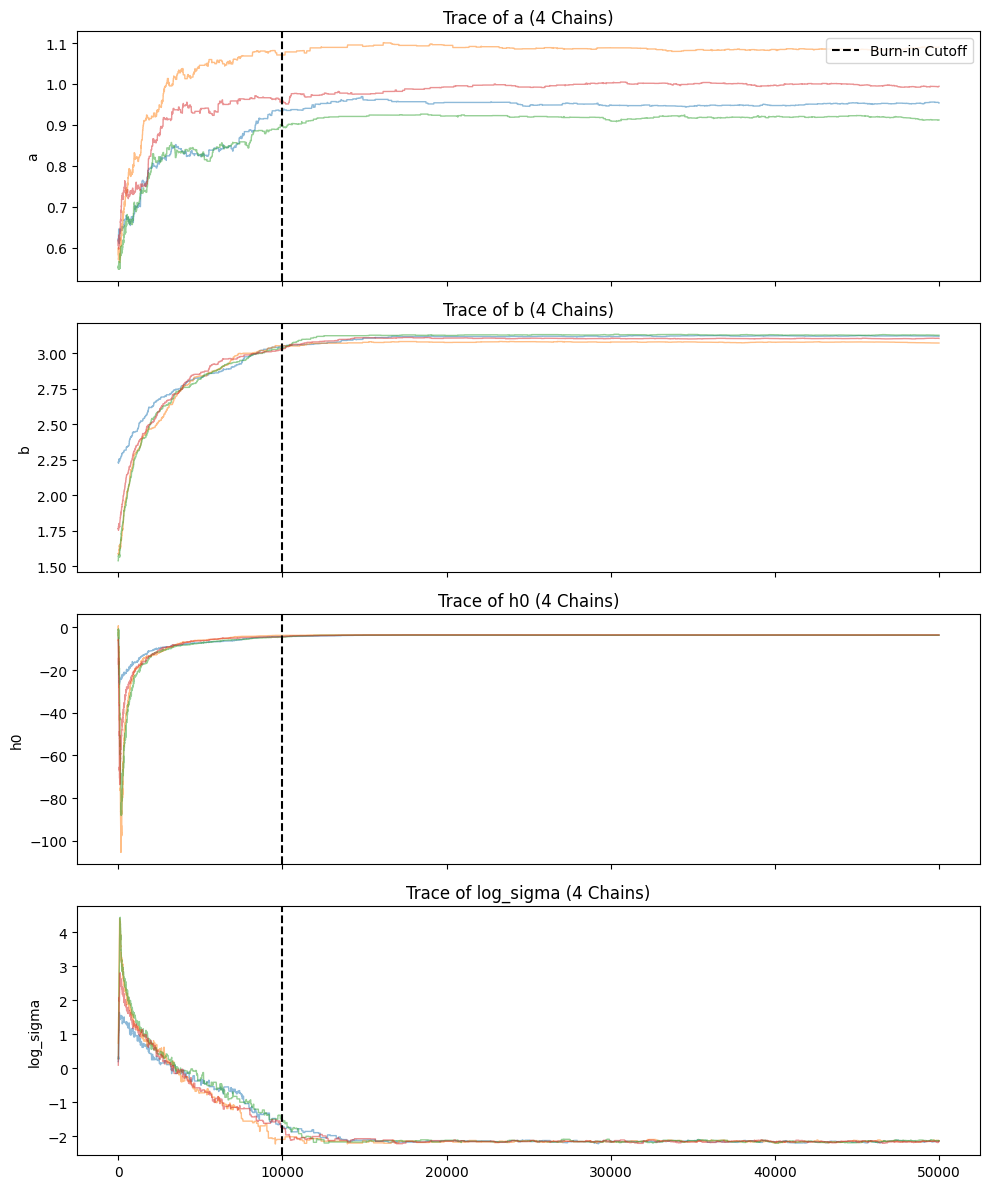

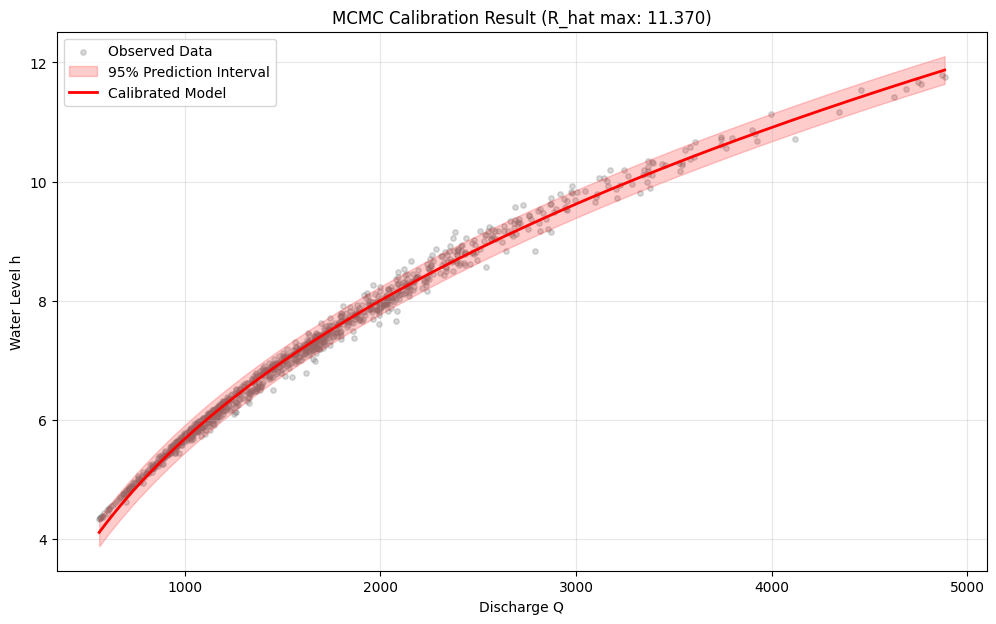

In [16]:
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Settings
n_chains = 4
n_iterations = 50000
burn_in = 10000

# Step sizes (Standard Deviations)
step_sizes = np.array([0.005, 0.005, 2.5, 0.1]) 

# Base guess for parameters [a, b, h0, log_sigma]
base_theta = np.array([0.6, 1.8, -2.0, 0.2])

# Storage for results
all_chains_full = [] 
all_chains_burned = [] 

# 2. Run Multiple Chains
print(f"--- Starting {n_chains} MCMC Chains ---")

for i in range(n_chains):
    # randomize starting point slightly for each chain
    noise = np.random.normal(0, 1, 4) * np.array([0.02, 0.2, 5.0, 0.5])
    start_theta = np.abs(base_theta + noise)
    
    # Ensure h0 is reasonable (negative)
    start_theta[2] = -np.abs(start_theta[2]) 
    
    # Run
    chain_res = run_mcmc_chain(i+1, n_iterations, start_theta, step_sizes, Q_combined, h_combined)
    
    all_chains_full.append(chain_res)
    all_chains_burned.append(chain_res[burn_in:])

# Convert to 3D Arrays
chains_burned_array = np.array(all_chains_burned) # Shape (4, 30000, 4)
chains_full_array = np.array(all_chains_full)     # Shape (4, 50000, 4)

# 3. Calculate Gelman-Rubin R_hat
r_hat_values = calculate_r_hat(chains_burned_array)
param_labels = ['a', 'b', 'h0', 'log_sigma']

print("\n--- Gelman-Rubin Convergence Diagnostics ---")
print("Target: R_hat < 1.05")
for name, r_val in zip(param_labels, r_hat_values):
    status = "CONVERGED" if r_val < 1.05 else "NOT CONVERGED"
    print(f"{name:10} : {r_val:.5f}  [{status}]")

# 4. Calculate Final Estimates (Combine all chains)
# Flatten the 4 chains into one giant list of samples
combined_samples = chains_burned_array.reshape(-1, 4)

a_est = np.mean(combined_samples[:, 0])
b_est = np.mean(combined_samples[:, 1])
h0_est = np.mean(combined_samples[:, 2])
sigma_est = np.exp(np.mean(combined_samples[:, 3]))

print("\n--- Final Calibrated Parameters ---")
print(f"a  : {a_est:.4f}")
print(f"b  : {b_est:.4f}")
print(f"h0 : {h0_est:.4f}")
print(f"sigma : {sigma_est:.4f}")

# 5. Visualizations
# A. Trace Plots (Show all 4 chains)
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Blue, Orange, Green, Red

for j, ax in enumerate(axes):
    for c in range(n_chains):
        # Plot full history to see the start point
        ax.plot(chains_full_array[c, :, j], color=colors[c], alpha=0.5, linewidth=1)
    
    ax.axvline(burn_in, color='black', linestyle='--', label='Burn-in Cutoff')
    ax.set_ylabel(param_labels[j])
    ax.set_title(f"Trace of {param_labels[j]} (4 Chains)")
    if j==0: ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# B. Model Fit
plt.figure(figsize=(12, 7))
plt.scatter(Q_combined, h_combined, alpha=0.3, label='Observed Data', color='gray', s=15)

# Generate Model Curve
Q_range = np.linspace(np.min(Q_combined), np.max(Q_combined), 200)
h_mean_fit = stage_discharge_model(Q_range, a_est, b_est, h0_est)

# Prediction Intervals
upper_bound = h_mean_fit + 1.96 * sigma_est
lower_bound = h_mean_fit - 1.96 * sigma_est

plt.fill_between(Q_range, lower_bound, upper_bound, color='red', alpha=0.2, label='95% Prediction Interval')
plt.plot(Q_range, h_mean_fit, color='red', linewidth=2, label='Calibrated Model')

plt.xlabel("Discharge Q")
plt.ylabel("Water Level h")
plt.title(f"MCMC Calibration Result (R_hat max: {np.max(r_hat_values):.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


##### option 2

--- Starting 4 MCMC Chains ---
Chain 1 started at: [ 0.794  1.987 -0.549  0.078]
Acceptance rate too high (32.40%), increasing step size.
Acceptance rate too low (14.93%), reducing step size.
Acceptance rate too low (11.45%), reducing step size.
Acceptance rate too low (9.24%), reducing step size.
Acceptance rate too low (7.77%), reducing step size.
Acceptance rate too low (6.66%), reducing step size.
Acceptance rate too low (5.88%), reducing step size.
Acceptance rate too low (5.24%), reducing step size.
Acceptance rate too low (4.78%), reducing step size.
Acceptance rate too low (4.36%), reducing step size.
Acceptance rate too low (4.03%), reducing step size.
Acceptance rate too low (3.77%), reducing step size.
Acceptance rate too low (3.53%), reducing step size.
Acceptance rate too low (3.31%), reducing step size.
Acceptance rate too low (3.12%), reducing step size.
Acceptance rate too low (2.98%), reducing step size.
Acceptance rate too low (2.81%), reducing step size.
Acceptance r

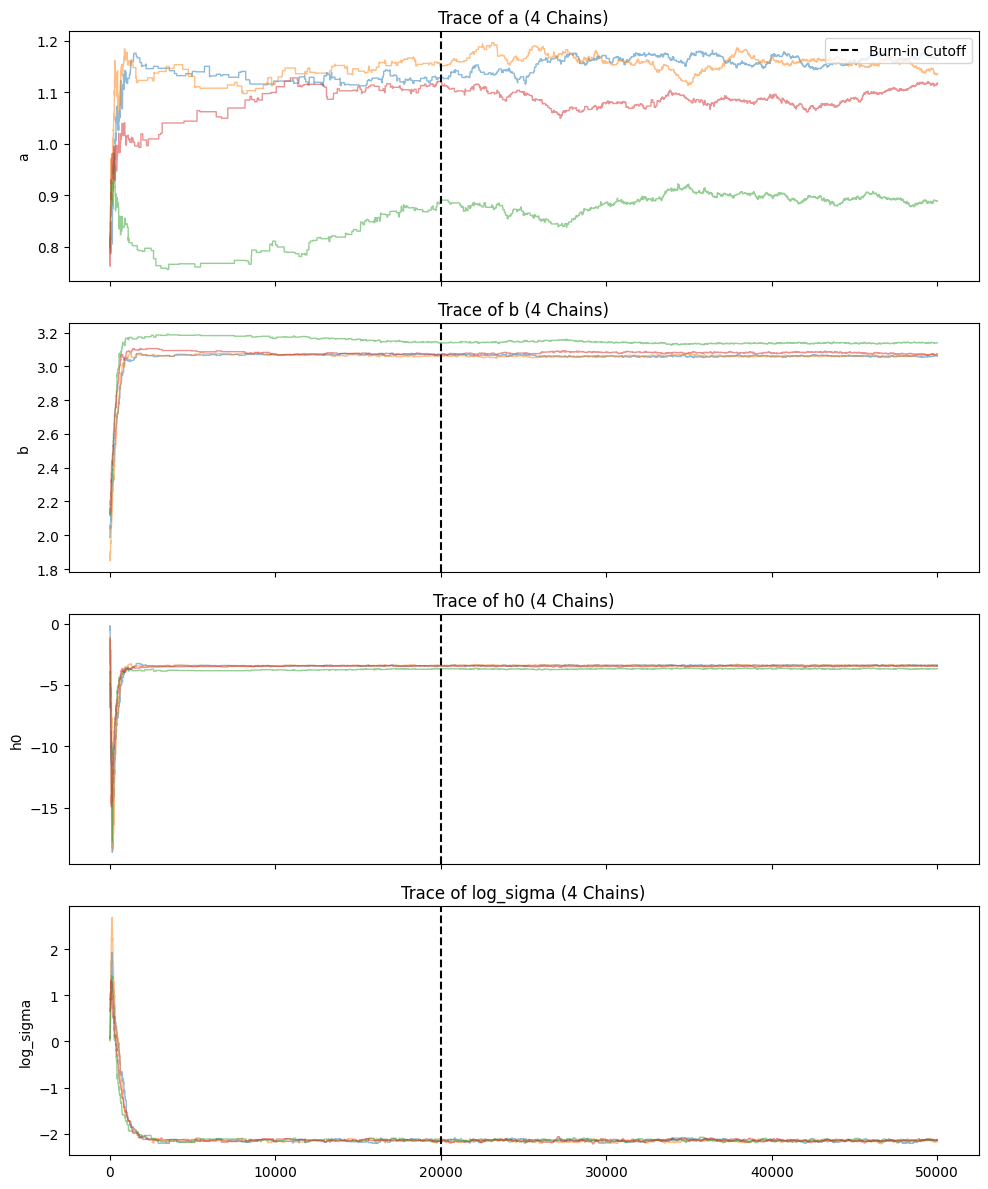

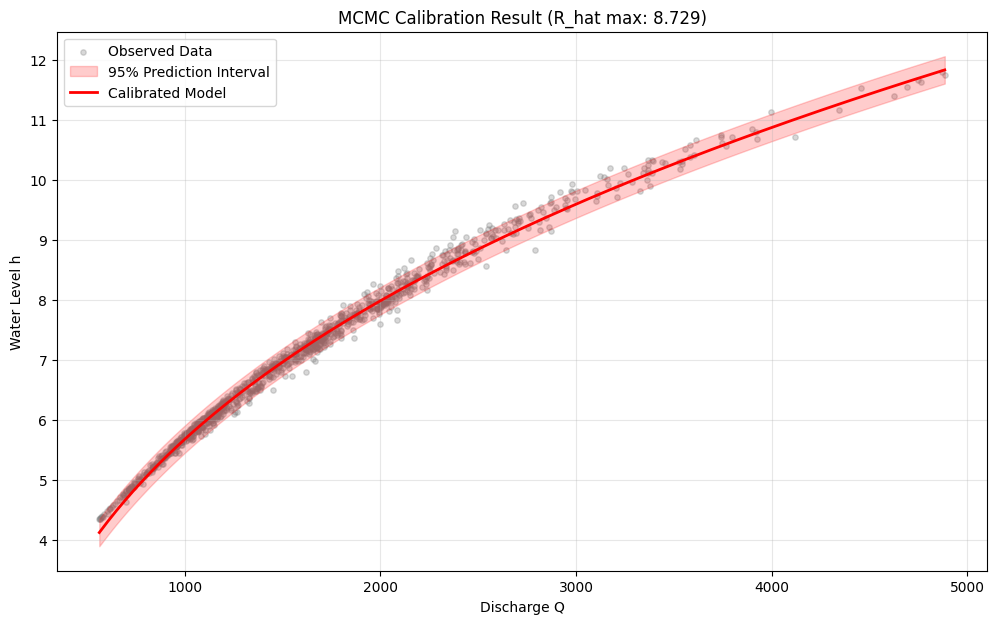

In [17]:
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Settings
n_chains = 4
n_iterations = 50000
burn_in = 20000

# Step sizes (Standard Deviations)
step_sizes = np.array([0.01, 0.01, 0.5, 0.05])

# Base guess for parameters [a, b, h0, log_sigma]
base_theta = np.array([0.8, 2.0, -2.5, 0.1]) 

# Storage for results
all_chains_full = [] # To store full history for plotting
all_chains_burned = [] # To store only valid samples for statistics

# 2. Run Multiple Chains
print(f"--- Starting {n_chains} MCMC Chains ---")

for i in range(n_chains):
    # randomize starting point slightly for each chain
    noise = np.random.normal(0, 1, 4) * np.array([0.02, 0.2, 5.0, 0.5])
    start_theta = np.abs(base_theta + noise)
    
    # Ensure h0 is reasonable (negative)
    start_theta[2] = -np.abs(start_theta[2]) 
    
    # Run
    chain_res = run_mcmc_chain(i+1, n_iterations, start_theta, step_sizes, Q_combined, h_combined)
    
    all_chains_full.append(chain_res)
    all_chains_burned.append(chain_res[burn_in:])

# Convert to 3D Arrays
chains_burned_array = np.array(all_chains_burned) # Shape (4, 30000, 4)
chains_full_array = np.array(all_chains_full)     # Shape (4, 50000, 4)

# 3. Calculate Gelman-Rubin R_hat
r_hat_values = calculate_r_hat(chains_burned_array)
param_labels = ['a', 'b', 'h0', 'log_sigma']

print("\n--- Gelman-Rubin Convergence Diagnostics ---")
print("Target: R_hat < 1.05")
for name, r_val in zip(param_labels, r_hat_values):
    status = "CONVERGED" if r_val < 1.05 else "NOT CONVERGED"
    print(f"{name:10} : {r_val:.5f}  [{status}]")

# 4. Calculate Final Estimates (Combine all chains)
# Flatten the 4 chains into one giant list of samples
combined_samples = chains_burned_array.reshape(-1, 4)

a_est = np.mean(combined_samples[:, 0])
b_est = np.mean(combined_samples[:, 1])
h0_est = np.mean(combined_samples[:, 2])
sigma_est = np.exp(np.mean(combined_samples[:, 3]))

print("\n--- Final Calibrated Parameters ---")
print(f"a  : {a_est:.4f}")
print(f"b  : {b_est:.4f}")
print(f"h0 : {h0_est:.4f}")
print(f"sigma : {sigma_est:.4f}")

# 5. Visualizations
# A. Trace Plots (Show all 4 chains)
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Blue, Orange, Green, Red

for j, ax in enumerate(axes):
    for c in range(n_chains):
        # Plot full history to see the start point
        ax.plot(chains_full_array[c, :, j], color=colors[c], alpha=0.5, linewidth=1)
    
    ax.axvline(burn_in, color='black', linestyle='--', label='Burn-in Cutoff')
    ax.set_ylabel(param_labels[j])
    ax.set_title(f"Trace of {param_labels[j]} (4 Chains)")
    if j==0: ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# B. Model Fit
plt.figure(figsize=(12, 7))
plt.scatter(Q_combined, h_combined, alpha=0.3, label='Observed Data', color='gray', s=15)

# Generate Model Curve
Q_range = np.linspace(np.min(Q_combined), np.max(Q_combined), 200)
h_mean_fit = stage_discharge_model(Q_range, a_est, b_est, h0_est)

# Prediction Intervals
upper_bound = h_mean_fit + 1.96 * sigma_est
lower_bound = h_mean_fit - 1.96 * sigma_est

plt.fill_between(Q_range, lower_bound, upper_bound, color='red', alpha=0.2, label='95% Prediction Interval')
plt.plot(Q_range, h_mean_fit, color='red', linewidth=2, label='Calibrated Model')

plt.xlabel("Discharge Q")
plt.ylabel("Water Level h")
plt.title(f"MCMC Calibration Result (R_hat max: {np.max(r_hat_values):.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


To continue for next time: Your model is seeing thousands of "normal" days (low/medium discharge) and very few "extreme" days (high discharge). Because standard MCMC (and Least Squares) tries to minimize the total error, it prioritizes fitting the thousands of normal days perfectly. If the river behaves slightly differently at high water (e.g., due to floodplains), the "normal" days drag the curve away from the "extreme" data points, causing the overestimation you see at the tail.

Since your research question (RQ3 in the MORE PDF ) is specifically about dike overtopping and extreme events, you should prioritize the fit of the upper tail over the lower days. Solution 1: Threshold Calibration (Recommended for Flood Projects)
Calibrate your model using only the upper half of your data. This forces the MCMC to ignore the low-flow days and find the perfect curve for high-water events.

How to apply it: Modify your training data selection (the split step) to filter out low discharges.
# ... (Previous merging code) ...

# 1. Filter Training Data for High Flows ONLY
# We only train on Q > 2000 (approx median) to prioritize the flood tail.
high_flow_mask = combined_df['Q_m3s'] > 2000 
training_data = combined_df.loc['2022-01-01':'2023-12-31']
training_data = training_data[training_data['Q_m3s'] > 2000] # <--- ADD THIS FILTER

# Validation can keep all data to check overall performance
validation_data = combined_df.loc['2024-01-01':'2024-12-31']

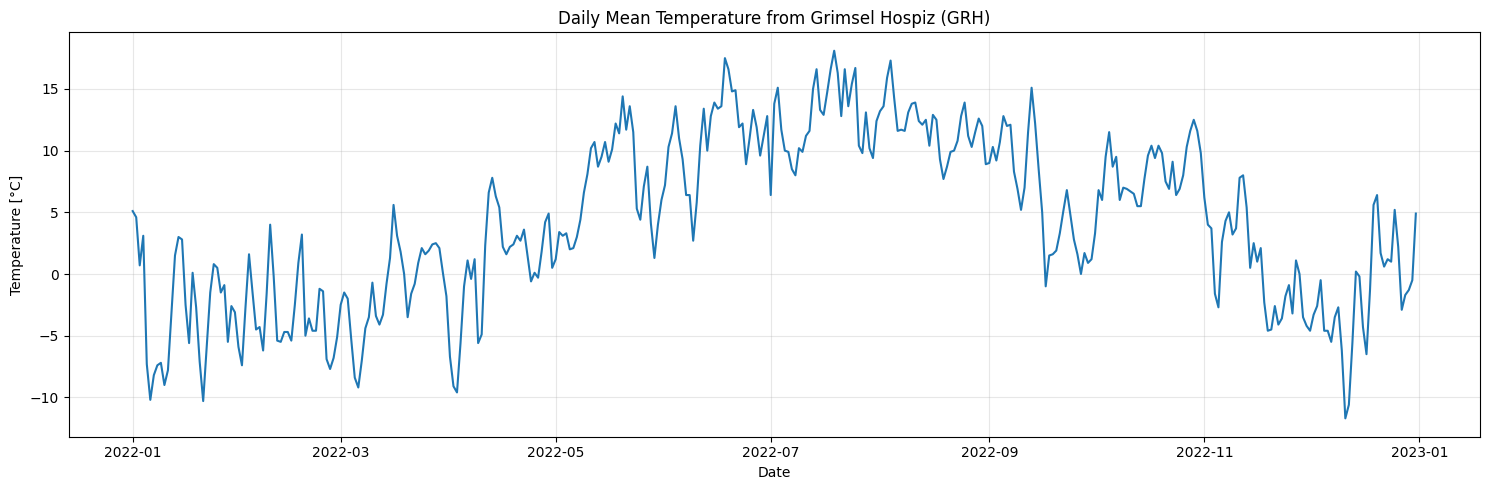

In [18]:
file_name = 'data/ogd-nbcn_grh_d_historical.csv' 


df = pd.read_csv(file_name, sep=';', encoding="latin1")
df["datum"] = pd.to_datetime(df["reference_timestamp"], dayfirst=True)


df["temperature"] = pd.to_numeric(
    df["ths200d0"].astype(str).str.replace(",", "."), errors='coerce'
)

df = df.dropna(subset=["datum", "temperature"])

# 2. Fix: Grouping is unnecessary. Set the 'datum' as the index for time series plotting.
df = df.set_index("datum").sort_index()

one_yeardaily = df.loc['2022-01-01':'2022-12-31'].copy()

# 3. Plotting
plt.figure(figsize=(15, 5))

# Plot the index (Date) vs the temperature column values
plt.plot(one_yeardaily.index, one_yeardaily["temperature"].values)

# 4. Fix: Correcting the Y-axis label from "Discharge" to "Temperature"
plt.xlabel("Date")
plt.ylabel("Temperature [°C]")
plt.title(f"Daily Mean Temperature from Grimsel Hospiz (GRH)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


DatetimeIndex(['2022-01-01', '2022-01-02', '2022-01-03', '2022-01-04',
               '2022-01-05', '2022-01-06', '2022-01-07', '2022-01-08',
               '2022-01-09', '2022-01-10',
               ...
               '2024-12-22', '2024-12-23', '2024-12-24', '2024-12-25',
               '2024-12-26', '2024-12-27', '2024-12-28', '2024-12-29',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', name='datum', length=1096, freq=None)


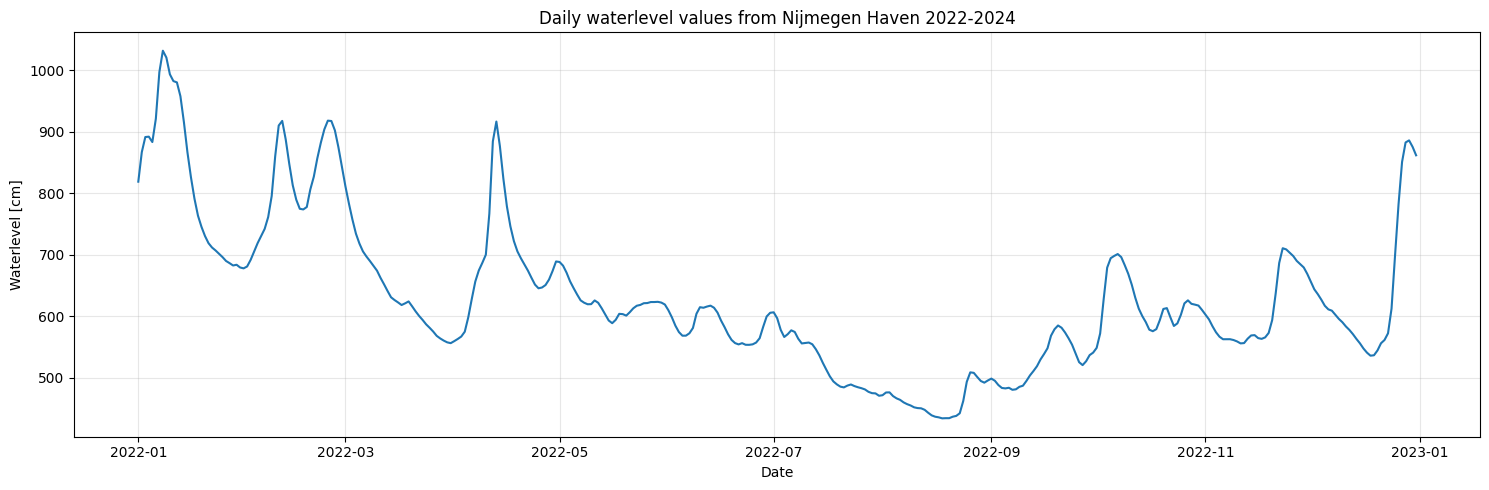

In [19]:
filename = 'data/nijmegen_haven_2022-2024.csv'
df_h = pd.read_csv(filename, sep=';', encoding="latin1")
df_h["datum"] = pd.to_datetime(df_h["WAARNEMINGDATUM"],dayfirst=True)
df_h["waarde"] = pd.to_numeric(df_h["NUMERIEKEWAARDE"].astype(str).str.replace(",", "."))
df_h.loc[df_h["waarde"] > 1e5, "waarde"] = np.nan # remove outliers
df_h = df_h.dropna(subset=["datum", "waarde"]) # drop rows with NaN in 'datum' or 'waarde'
h_series = df_h.groupby("datum")["waarde"].mean() # transform to daily mean 
print(h_series.index)

one_year = h_series[:365]

plt.figure(figsize=(15, 5))
plt.plot(one_year.index, one_year.values)
plt.xlabel("Date")
plt.ylabel("Waterlevel [cm]")
plt.title(f"Daily waterlevel values from Nijmegen Haven 2022-2024")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()